# 基于推理的词分布的表示方法与Word2Vec模型

在对本文的分布式假设中（用向量表示单词），大致可以分为两种比较成功的方式：一是基于计数的方法（如共现矩阵、PPMI矩阵），另一种是基于推理的方法。

### 基于计数的方法存在的问题

基于计数的方法根据一个单词周围的单词的出现频数来表示该单词。具体来说，先生成所有单词的共现矩阵，再对这个矩阵进行SVD，以获得密集向量（单词的分布式表示）​。

但是，基于计数的方法在处理大规模语料库时会出现问题。如果词汇量超过100万个，那么使用基于计数的方法就需要生成一个100万×100万的庞大矩阵，但对如此庞大的矩阵执行SVD显然是不现实的。

### Tip：SVD的局限性

如果词汇量超过100万个，那么使用基于计数的方法就需要生成一个100万×100万的庞大矩阵，但对如此庞大的矩阵执行SVD显然是不现实的。

### 计数与推理的差异

基于计数的方法使用整个语料库的统计数据（共现矩阵和PPMI等）​，通过一次处理（SVD等）获得单词的分布式表示。而基于推理的方法使用神经网络，通常在mini-batch数据上进行学习。这意味着神经网络一次只需要看一部分学习数据（mini-batch）​，并反复更新权重。这种学习机制上的差异如图3-1所示。

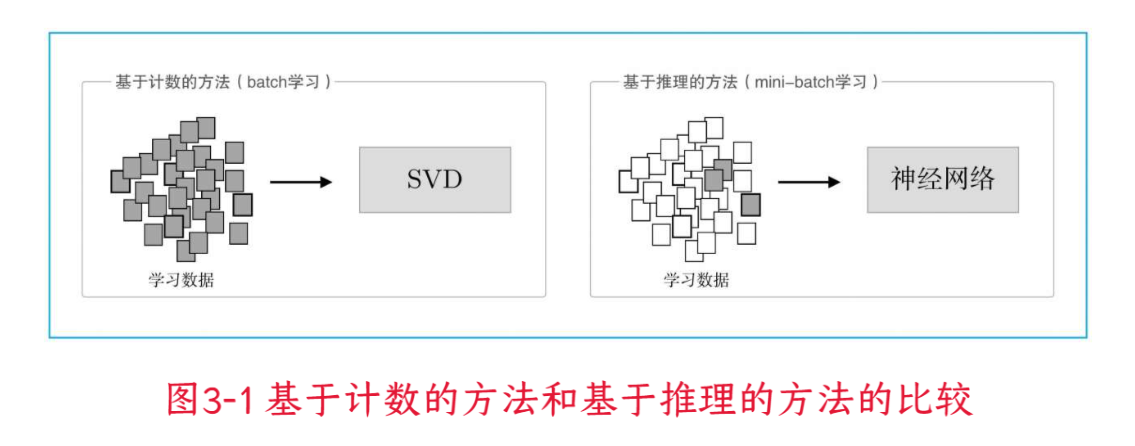

如图3-1所示，基于计数的方法一次性处理全部学习数据；反之，基于推理的方法使用部分学习数据逐步学习。这意味着，在词汇量很大的语料库中，即使SVD等的计算量太大导致计算机难以处理，神经网络也可以在部分数据上学习。并且，神经网络的学习可以使用多台机器、多个GPU并行执行，从而加速整个学习过程。在这方面，基于推理的方法更有优势。

### 基于推理的方法的概要

基于推理的方法的主要操作是“推理”​。如图3-2所示，当给出周围的单词（上下文）时，预测“?”处会出现什么单词，这就是推理。

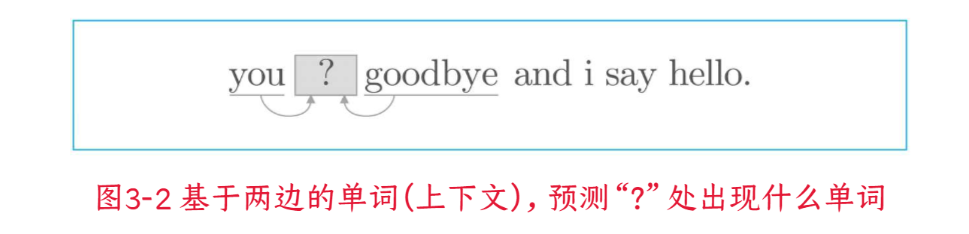

解开图3-2中的推理问题并学习规律，就是基于推理的方法的主要任务。通过反复求解这些推理问题，可以学习到单词的出现模式。从“模型视角”出发，这个推理问题如图3-3所示。

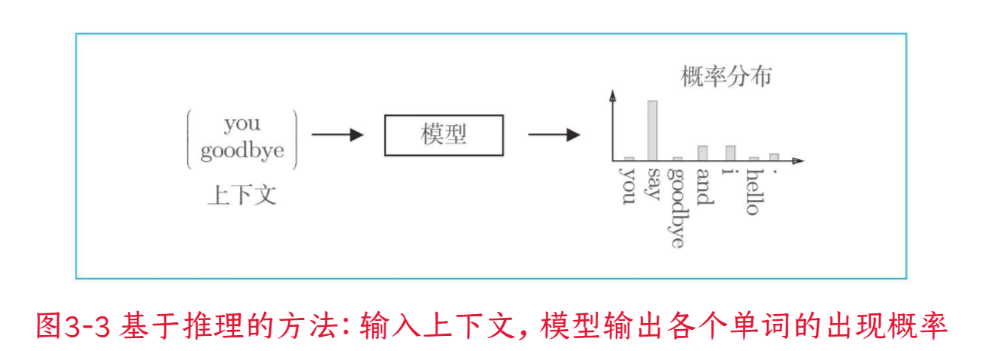

如图3-3所示，基于推理的方法引入了某种模型，我们将神经网络用于此模型。这个模型接收上下文信息作为输入，并输出（可能出现的）各个单词的出现概率。在这样的框架中，使用语料库来学习模型，使之能做出正确的预测。另外，作为模型学习的产物，我们得到了单词的分布式表示。这就是基于推理的方法的全貌。

### Tip：单词共现建模

基于推理的方法和基于计数的方法一样，也基于分布式假设。分布式假设假设“单词含义由其周围的单词构成”​。基于推理的方法将这一假设归结为了上面的预测问题。由此可见，不管是哪种方法，如何对基于分布式假设的“单词共现”建模都是最重要的研究主题。

### 神经网络如何处理单词

从现在开始，我们将使用神经网络来处理单词。但是，神经网络无法直接处理you或say这样的单词，要用神经网络处理单词，需要先将单词转化为固定长度的向量。对此，一种方式是将单词转换为one-hot表示（one-hot向量）​。在one-hot表示中，只有一个元素是1，其他元素都是0。

我们来看一个one-hot表示的例子。和上一章一样，我们用“You say goodbye and I say hello.”这个一句话的语料库来说明。在这个语料库中，一共有7个单词（​“you”​“say”​“goodbye”​“and”​“i”​“hello”​“.”​）​。此时，各个单词可以转化为图3-4所示的one-hot表示。

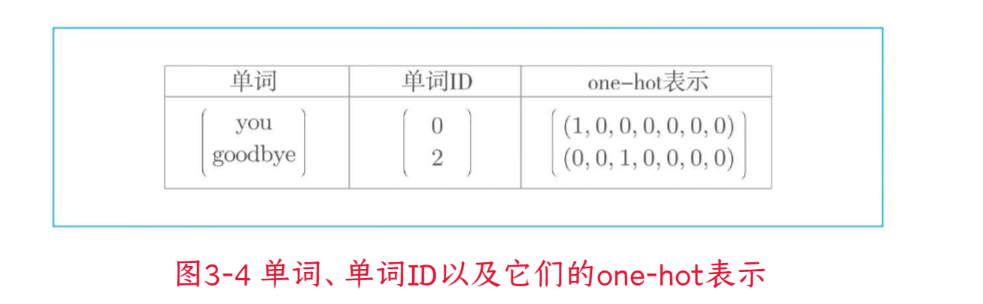

如图3-4所示，单词可以表示为文本、单词ID和one-hot表示。此时，要将单词转化为one-hot表示，就需要准备元素个数与词汇个数相等的向量，并将单词ID对应的元素设为1，其他元素设为0。像这样，只要将单词转化为固定长度的向量，神经网络的输入层的神经元个数就可以固定下来（图3-5）​。

这样就可以固定输入层的数据形状。

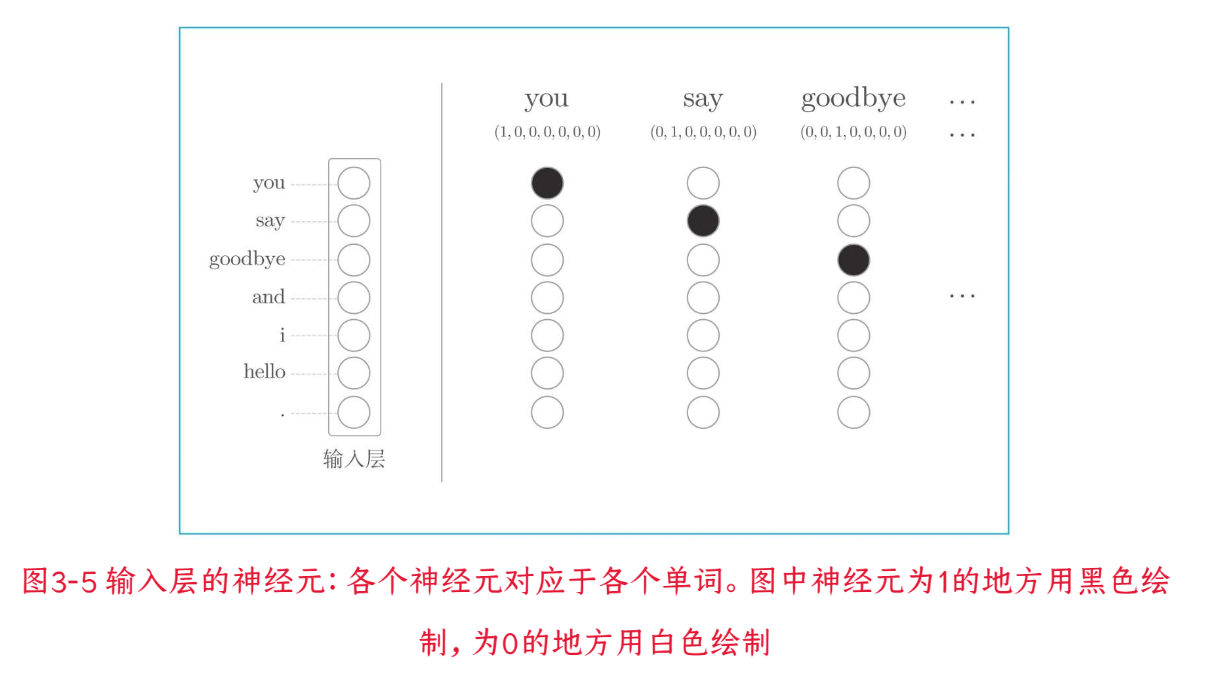

如图3-5所示，输入层由7个神经元表示，分别对应于7个单词（第1个神经元对应于you，第2个神经元对应于say）​。现在事情变得很简单了。因为只要将单词表示为向量，这些向量就可以由构成神经网络的各种“层”来处理。比如，对于one-hot表示的某个单词，使用全连接层对其进行变换的情况如图3-6所示。

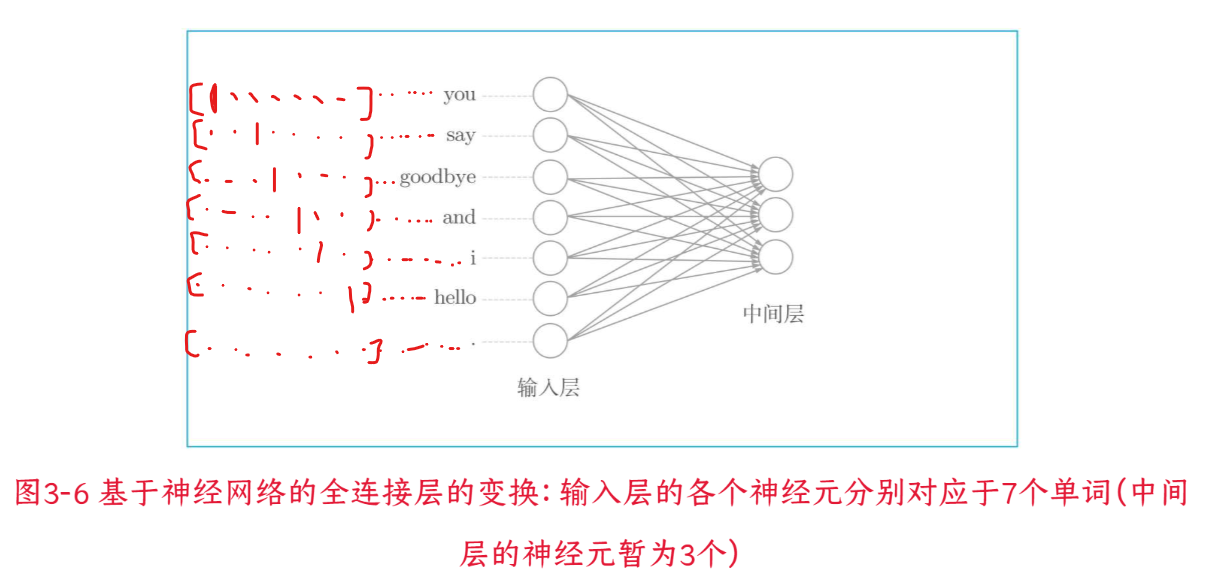

如图3-6所示，全连接层通过箭头连接所有节点。这些箭头拥有权重（参数）​，它们和输入层神经元的加权和成为中间层的神经元。另外，本章使用的全连接层将省略偏置（这是为了配合后文对word2vec的说明）​。

### Tip:MatMul（矩阵乘积）

没有偏置的全连接层相当于在计算矩阵乘积。在很多深度学习的框架中，在生成全连接层时，都可以选择不使用偏置。在本书中，不使用偏置的全连接层相当于MatMul层（该层已经在第1章中实现）​。

在图3-6中，神经元之间的连接是用箭头表示的。之后，为了明确地显示权重，我们将使用图3-7所示的方法。"

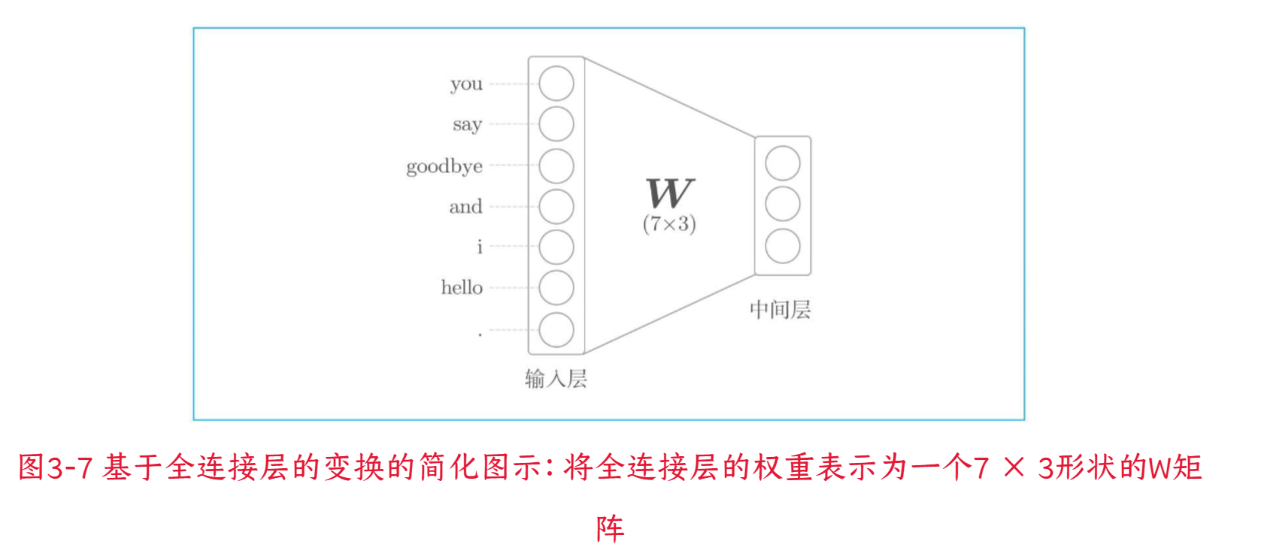

这里的全连接层变换可以写成如下的Python代码。

In [1]:
import numpy as np

c = np.array([1,0,0,0,0,0,0])# 输入：you的变量
W = np.random.randn(7,3)# 初始化权重矩阵
h = np.dot(c,W)# 首层神经元计算（MatMul）
print(h)# 中间神经元输出结果（without bias）


[-0.31482257 -1.57475412  0.04942596]


这段代码将单词ID为0的单词表示为了one-hot表示，并用全连接层对其进行了变换。作为复习，全连接层的计算通过矩阵乘积进行。这可以用NumPy的np.dot（​）来实现（省略偏置）​。

这里，输入数据（变量c）的维数（ndim）是2。这是考虑了mini-batch处理，将各个数据保存在了第1维（0维度）中。

注意一下c和W进行矩阵乘积计算的地方。此处，c是one-hot表示，单词ID对应的元素是1，其他地方都是0。因此，如图3-8所示，上述代码中的c和W的矩阵乘积相当于“提取”权重的对应行向量。

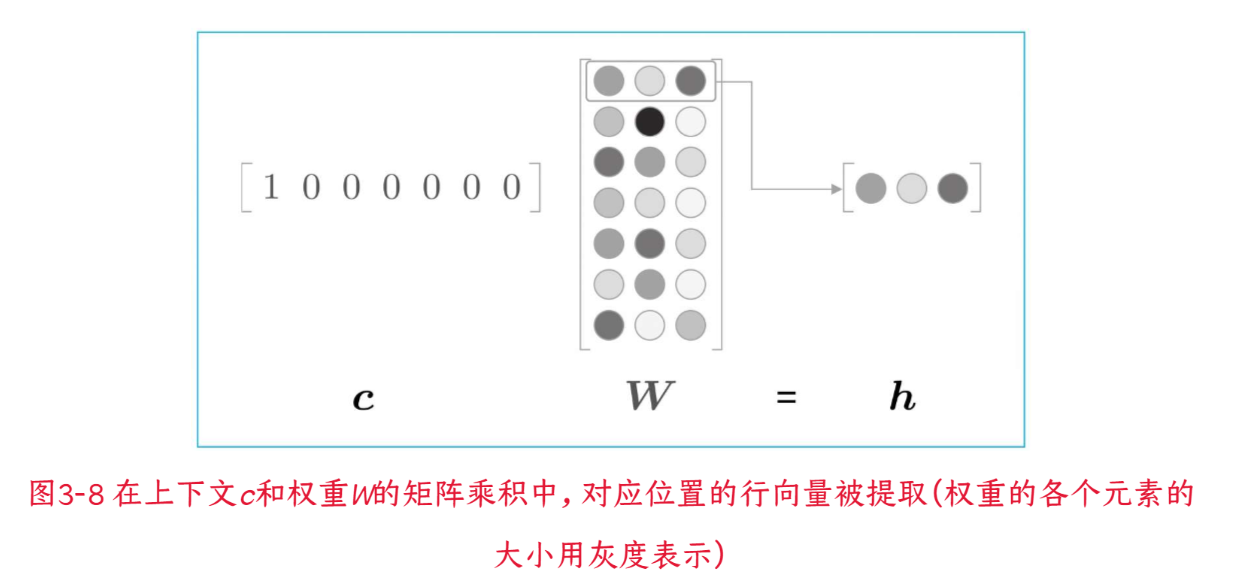

这里，仅为了提取权重的行向量而进行矩阵乘积计算好像不是很有效率。关于这一点，我们将在下节进行改进。另外，上述代码的功能也可以使用第1章中实现的MatMul层完成，如下所示。

In [2]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul

c = np.array([1,0,0,0,0,0,0])
W = np.random.randn(7,3)
layer = MatMul(W)
h = layer.forward(c)
print(h)

[0.36477893 0.75509463 1.30175295]


### 简易的Word2Vec

word2vec一词最初用来指程序或者工具，但是随着该词的流行，在某些语境下，也指神经网络的模型。正确地说，CBOW模型和skip-gram模型是word2vec中使用的两个神经网络。本节我们将主要讨论CBOW模型。关于这两个模型的差异，我们将在后面章节详细介绍。

### CBOW模型的推理

CBOW模型是根据上下文预测目标词的神经网络（​“目标词”是指中间的单词，它周围的单词是“上下文”​）​。通过训练这个CBOW模型，使其能尽可能地进行正确的预测，我们可以获得单词的分布式表示。

CBOW模型的输入是上下文。这个上下文用['you', 'goodbye']这样的单词列表表示。我们将其转换为one-hot表示，以便CBOW模型可以进行处理。在此基础上，CBOW模型的网络可以画成图3-9这样。

图3-9是CBOW模型的网络。它有两个输入层，经过中间层到达输出层。这里，从输入层到中间层的变换由相同的全连接层（权重为Win）完成，从中间层到输出层神经元的变换由另一个全连接层（权重为Wout）完成。

这里，因为我们对上下文仅考虑两个单词，所以输入层有两个。如果对上下文考虑N个单词，则输入层会有N个。

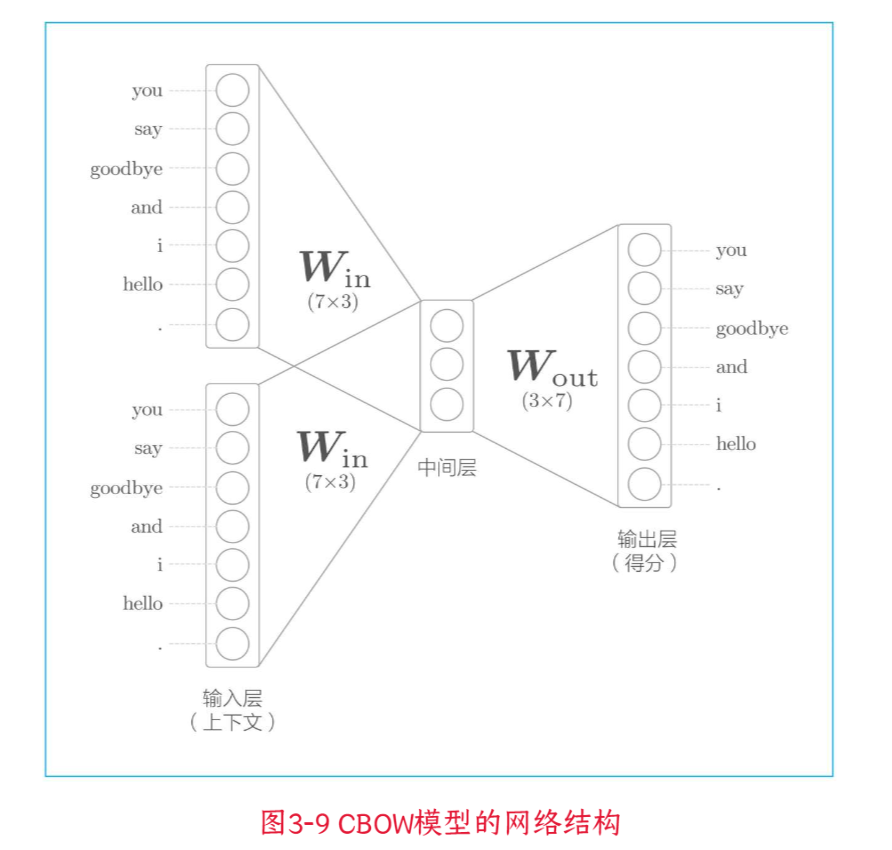

现在，我们注意一下图3-9的中间层。此时，中间层的神经元是各个输入层经全连接层变换后得到的值的“平均”​。就上面的例子而言，经全连接层变换后，第1个输入层转化为h1，第2个输入层转化为h2，那么中间层的神经元是$\frac{1}{2}(h_1+h_2)$。

最后是图3-9中的输出层，这个输出层有7个神经元。这里重要的是，这些神经元对应于各个单词。输出层的神经元是各个单词的得分，它的值越大，说明对应单词的出现概率就越高。得分是指在被解释为概率之前的值，对这些得分应用Softmax函数，就可以得到概率。

### Tip:输出层
有时将得分经过Softmax层之后的神经元称为输出层。这里，我们将输出得分的节点称为输出层。

如图3-9所示，从输入层到中间层的变换由全连接层（权重是Win）完成。此时，全连接层的权重Win是一个7×3的矩阵。提前剧透一下，这个权重就是我们要的单词的分布式表示，如图3-10所示。

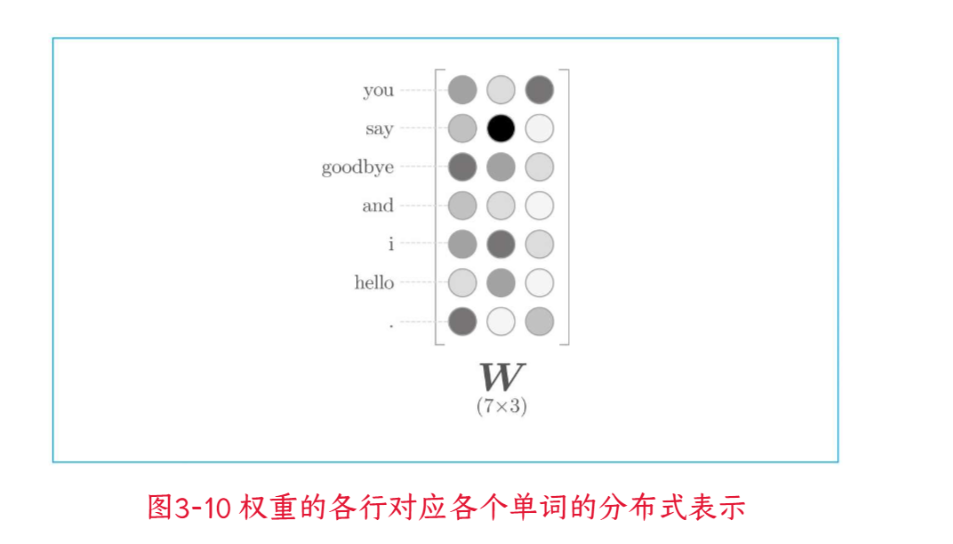

如图3-10所示，权重Win的各行保存着各个单词的分布式表示。通过反复学习，不断更新各个单词的分布式表示，以正确地从上下文预测出应当出现的单词。令人惊讶的是，如此获得的向量很好地对单词含义进行了编码。这就是word2vec的全貌。

### Tip：中间层——压缩编码

中间层的神经元数量比输入层少这一点很重要。中间层需要将预测单词所需的信息压缩保存，从而产生密集的向量表示。这时，中间层被写入了我们人类无法解读的代码，这相当于“编码”工作。而从中间层的信息获得期望结果的过程则称为“解码”​。这一过程将被编码的信息复原为我们可以理解的形式。

到目前为止，我们从神经元视角图示了CBOW模型。下面，我们从层视角图示CBOW模型。这样一来，这个神经网络的结构如图3-11所示。

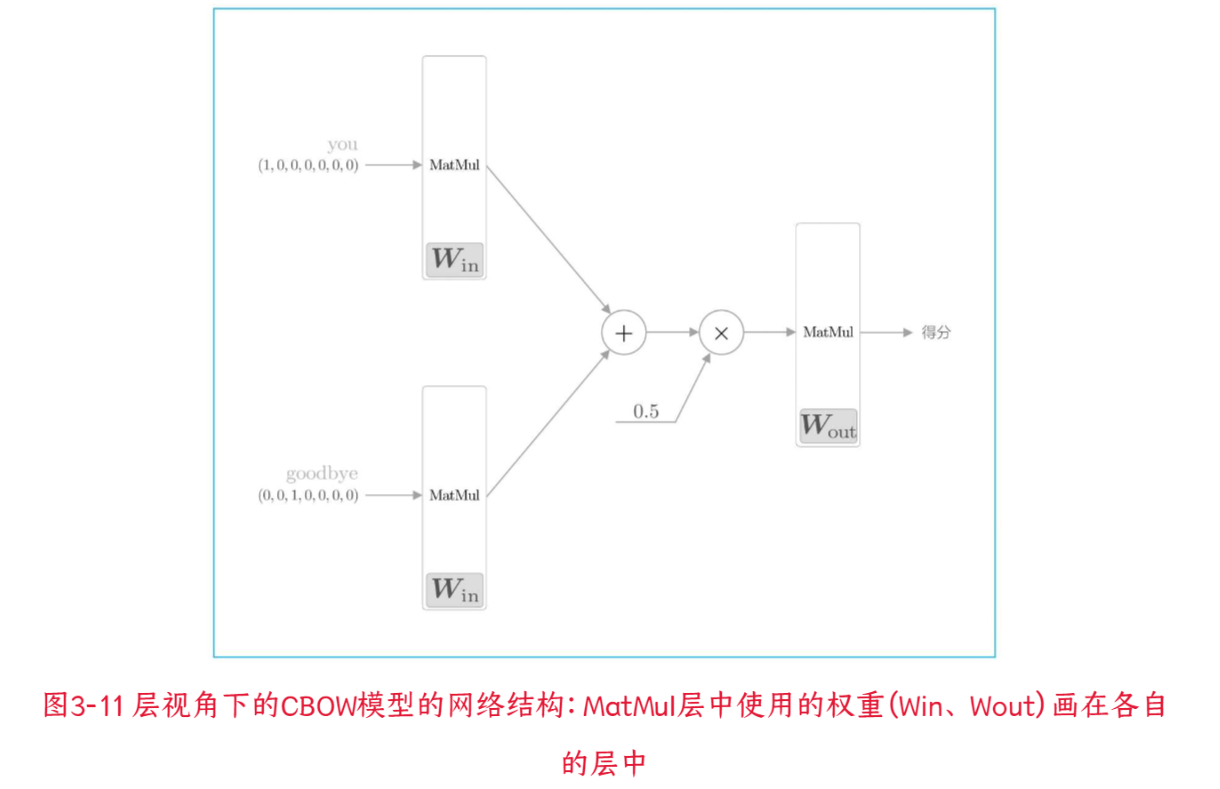

如图3-11所示，CBOW模型一开始有两个MatMul层，这两个层的输出被加在一起。然后，对这个相加后得到的值乘以0.5求平均，可以得到中间层的神经元。最后，将另一个MatMul层应用于中间层的神经元，输出得分。

不使用偏置的全连接层的处理由MatMul层的正向传播代理。这个层在内部计算矩阵乘积。

参考图3-11，我们来实现CBOW模型的推理（即求得分的过程）​，具体实现如下所示：

In [3]:
# you say goodbey and i say hello.

import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul

# 样本的上下文数据
c0 = np.array([1,0,0,0,0,0,0])
c1 = np.array([0,0,1,0,0,0,0])

# 权重的初始值
W_in = np.random.randn(7,3)
W_out = np.random.randn(3,7)

# 生成层<Model-Init>、<每个层都是一个单独的MatMul对象>(将初始权重赋值给模型——生成初始模型参数)
in_layer0 = MatMul(W_in)# 
in_layer1 = MatMul(W_in)# 
out_layer = MatMul(W_out)#

# 正向传播
h0 = in_layer0.forward(c0)# 模拟第一层c0输入后的神经元结果
h1 = in_layer1.forward(c1)# 模拟第二层c1输入后的神经元结果
h = 0.5*(h0+h1)# 中间层神经元结果
s = out_layer.forward(h)# 模拟输出层的神经元结果

print(s)

# 输出得分最高的序号
s = list(s)
print(s.index(max(s)))

[-3.18781239 -1.26521595  0.96987027  1.59984077 -0.87877983  1.77415531
 -1.47957361]
5


这里，我们首先将必要的权重（W_in和W_out）初始化。然后，生成与上下文单词数量等量（这里是两个）的处理输入层的MatMul层，输出侧仅生成一个MatMul层。需要注意的是，输入侧的MatMul层共享权重W_in。

之后，输入侧的MatMul层（in_layer0和in_layer1）调用forward（​）方法，计算中间数据，并通过输出侧的MatMul层（out_layer）计算各个单词的得分。

以上就是CBOW模型的推理过程。这里我们见到的CBOW模型是没有使用激活函数的简单的网络结构。除了多个输入层共享权重外，并没有什么难点。接下来，我们继续看一下CBOW模型的学习。

### CBOW模型的学习

到目前为止，我们介绍的CBOW模型在输出层输出了各个单词的得分。通过对这些得分应用Softmax函数，可以获得概率（图3-12）​。这个概率表示哪个单词会出现在给定的上下文（周围单词）中间。

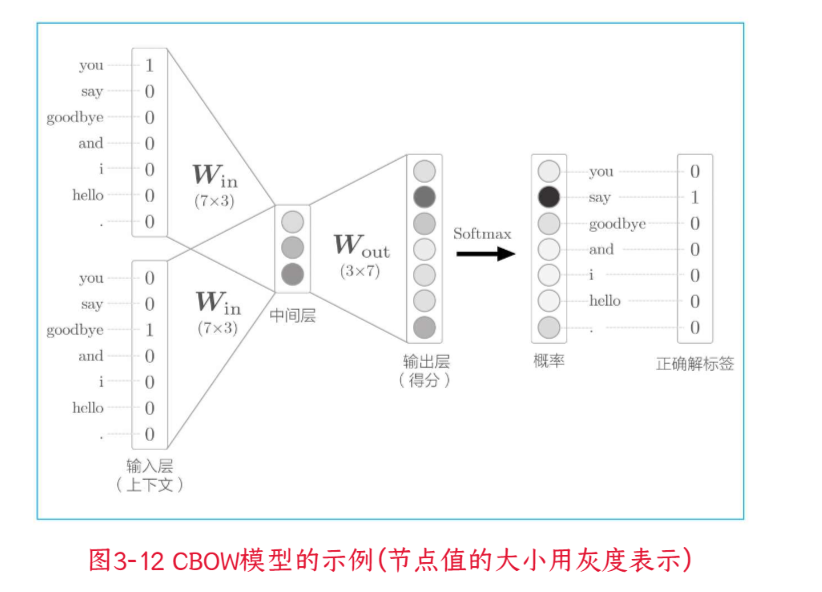

在图3-12所示的例子中，上下文是you和goodbye，正确解标签（神经网络应该预测出的单词）是say。这时，如果网络具有“良好的权重”​，那么在表示概率的神经元中，对应正确解的神经元的得分应该更高。

CBOW模型的学习就是调整权重，以使预测准确。其结果是，权重Win（确切地说是Win和Wout两者）学习到蕴含单词出现模式的向量。根据过去的实验，CBOW模型（和skip-gram模型）得到的单词的分布式表示，特别是使用维基百科等大规模语料库学习到的单词的分布式表示，在单词的含义和语法上符合我们直觉的案例有很多。

### Tip：CBOW模型的语料差异性

CBOW模型只是学习语料库中单词的出现模式。如果语料库不一样，学习到的单词的分布式表示也不一样。比如，只使用“体育”相关的文章得到的单词的分布式表示，和只使用“音乐”相关的文章得到的单词的分布式表示将有很大不同。

现在，我们来考虑一下上述神经网络的学习。其实很简单，这里我们处理的模型是一个进行多类别分类的神经网络。因此，对其进行学习只是使用一下Softmax函数和交叉熵误差。首先，使用Softmax函数将得分转化为概率，再求这些概率和监督标签之间的交叉熵误差，并将其作为损失进行学习，这一过程可以用图3-13表示。

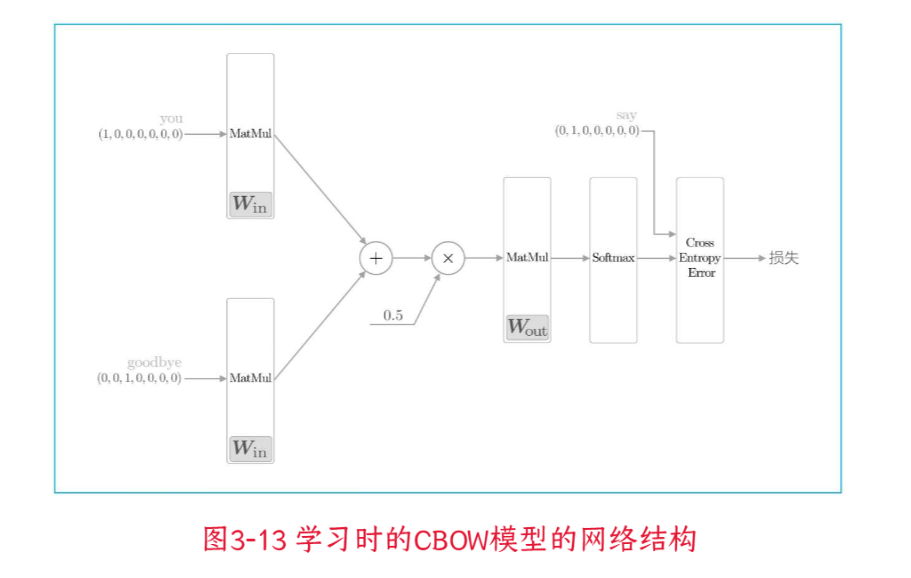

如图3-13所示，只需向上一节介绍的进行推理的CBOW模型加上Softmax层和Cross Entropy Error层，就可以得到损失。这就是CBOW模型计算损失的流程，对应于神经网络的正向传播。

虽然图3-13中使用了Softmax层和Cross Entropy Error层，但是我们将这两个层实现为了一个Softmax with Loss层。因此，我们接下来要实现的网络实际上如图3-14所示。

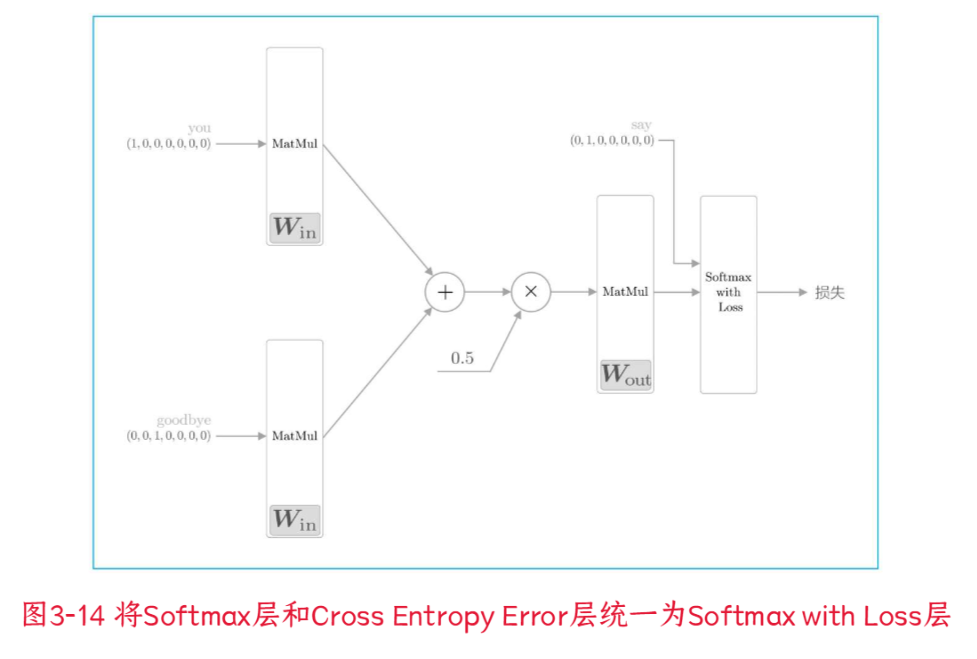

### Word2Vec的权重和分布式表示

如前所述，word2vec中使用的网络有两个权重，分别是输入侧的全连接层的权重（Win）和输出侧的全连接层的权重（Wout）​。一般而言，输入侧的权重Win的每一行对应于各个单词的分布式表示。另外，输出侧的权重Wout也同样保存了对单词含义进行了编码的向量。只是，如图3-15所示，输出侧的权重在列方向上保存了各个单词的分布式表示。

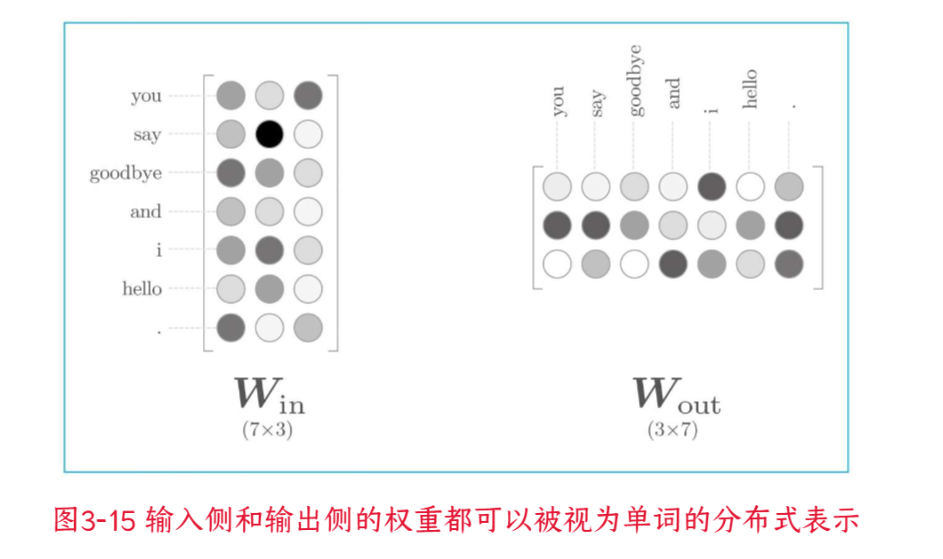

那么，我们最终应该使用哪个权重作为单词的分布式表示呢？这里有三个选项。

- A．只使用输入侧的权重
- B．只使用输出侧的权重
- C．同时使用两个权重

方案A和方案B只使用其中一个权重。而在采用方案C的情况下，根据如何组合这两个权重，存在多种方式，其中一个方式就是简单地将这两个权重相加。

就word2vec（特别是skip-gram模型）而言，最受欢迎的是方案A。许多研究中也都仅使用输入侧的权重Win作为最终的单词的分布式表示。遵循这一思路，我们也使用Win作为单词的分布式表示。

### Tip:Word2Vec的skip-gram模型中Win的有效性

文献通过实验证明了word2vec的skip-gram模型中Win的有效性。另外，在与word2vec相似的GloVe方法中，通过将两个权重相加，也获得了良好的结果。

### 文本数据预处理

在开始word2vec的学习之前，我们先来准备学习用的数据。这里我们仍以

“You say goodbye and I say hello.”

这个只有一句话的语料库为例进行说明。

### 上下文和目标词

（类似于完形填空，线索与答案的关系。）

word2vec中使用的神经网络的输入是上下文，它的正确解标签是被这些上下文包围在中间的单词，即目标词。也就是说，我们要做的事情是，当向神经网络输入上下文时，使目标词出现的概率高（为了达成这一目标而进行学习）​。

下面我们就从语料库生成上下文和目标词，如图3-16所示。

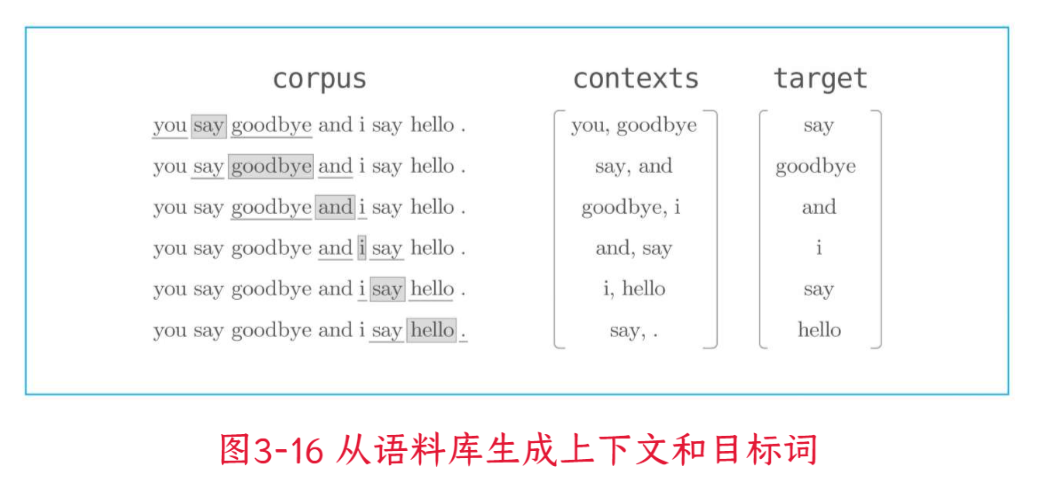

在图3-16中，将语料库中的目标单词作为目标词，将其周围的单词作为上下文提取出来。我们对语料库中的所有单词都执行该操作（两端的单词除外）​，可以得到图3-16右侧的contexts（上下文）和target（目标词）​。contexts的各行成为神经网络的输入，target的各行成为正确解标签（要预测出的单词）​。另外，在各笔样本数据中，上下文有多个单词（这个例子中有两个）​，而目标词则只有一个，因此只有上下文写成了复数形式contexts。

现在，我们来实现从语料库生成上下文和目标词的函数。在此之前，我们先复习一下上一章的内容。首先，将语料库的文本转化成单词ID。这需要使用前面实现的preprocess（​）函数。

In [4]:
import sys
sys.path.append('..')
from common.util import preprocess

text = 'you say hello and I say goodbey.'
corpus,word_to_id,id_to_word = preprocess(text)
print(corpus)
print(id_to_word)

[0 1 2 3 4 1 5 6]
{0: 'you', 1: 'say', 2: 'hello', 3: 'and', 4: 'i', 5: 'goodbey', 6: '.'}


然后，从单词ID列表corpus生成contexts和target。具体来说，如图3-17所示，实现一个当给定corpus时返回contexts和target的函数。

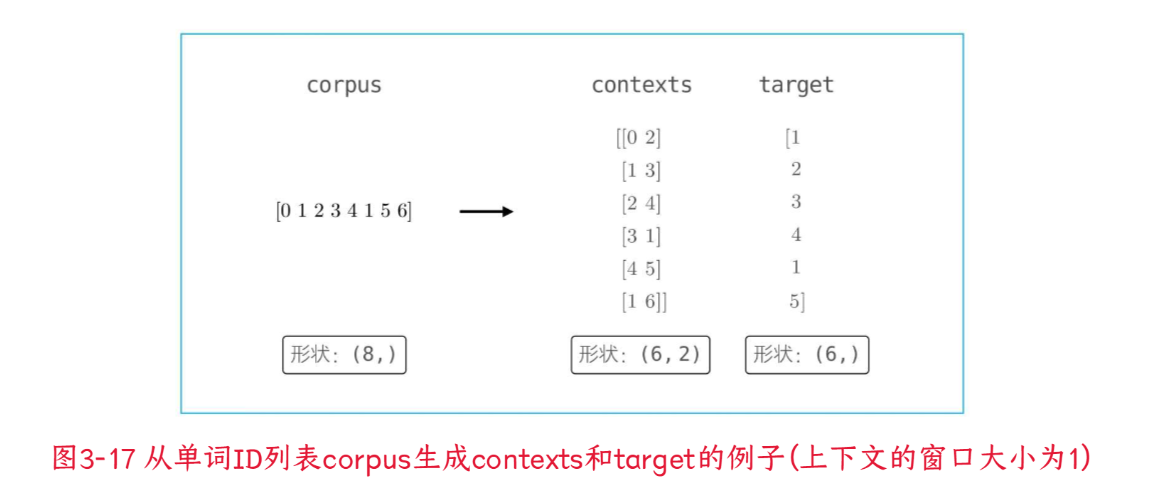

如图3-17所示，contexts是二维数组。此时，contexts的第0维保存的是各个上下文数据。具体来说，contexts[0]保存的是第0个上下文，context[1]保存的是第1个上下文……同样地，就目标词而言，target[0]保存的是第0个目标词，target[1]保存的是第1个目标词……

现在，我们来实现这个生成上下文和目标词的函数，这里将其称为create_contexts_target

In [5]:
def create_contexts_target(corpus, window_size=1):
    target = corpus[window_size:-window_size]
    contexts = []

    for idx in range(window_size, len(corpus) - window_size):
        cs = []
        for t in range(-window_size, window_size + 1):
            if t == 0:
                continue
            cs.append(corpus[idx + t])
        contexts.append(cs)

    return np.array(contexts), np.array(target)


这个函数有两个参数：一个是单词ID列表（corpus）​；另一个是上下文的窗口大小（window_size）​。另外，函数返回的是NumPy多维数组格式的上下文和目标词。现在，我们来实际使用一下这个函数，接着刚才的实现，代码如下所示。

In [6]:
# 调用函数并获取上下文和目标
contexts, target = create_contexts_target(corpus, window_size=1)
print(contexts)
print(target)

[[0 2]
 [1 3]
 [2 4]
 [3 1]
 [4 5]
 [1 6]]
[1 2 3 4 1 5]


这样就从语料库生成了上下文和目标词，后面只需将它们赋给CBOW模型即可。不过，因为这些上下文和目标词的元素还是单词ID，所以还需要将它们转化为one-hot表示。

###  转化为one-hot表示

下面，我们将上下文和目标词转化为one-hot表示，如图3-18所示。

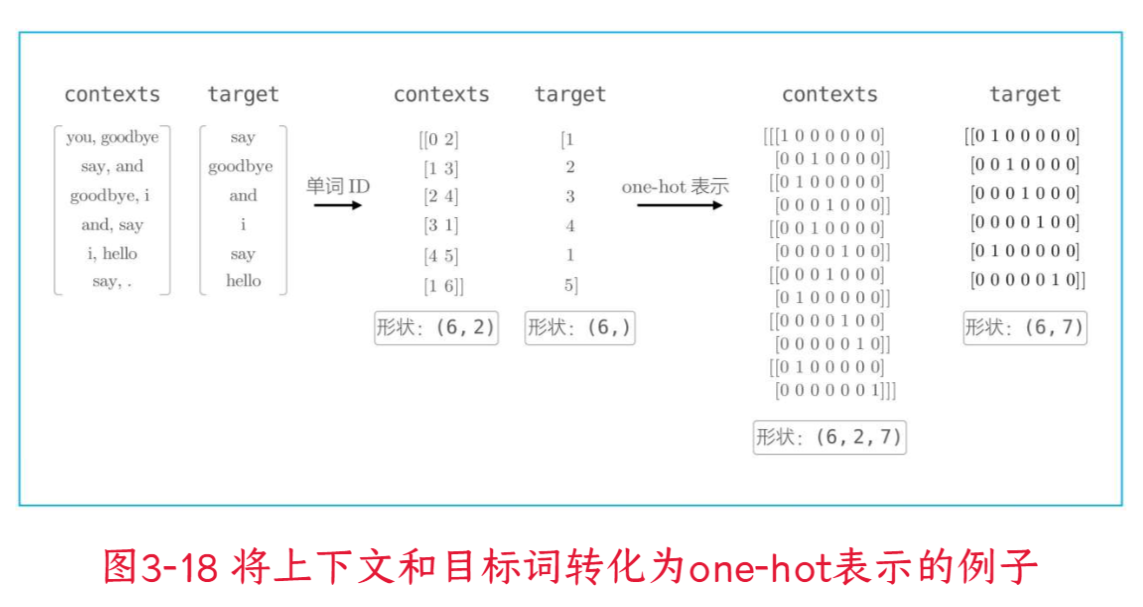

如图3-18所示，上下文和目标词从单词ID转化为了one-hot表示。这里需要注意各个多维数组的形状。在上面的例子中，使用单词ID时的contexts的形状是（6,2）​，将其转化为one-hot表示后，形状变为（6,2,7）​。

convert_one_hot（​）函数以将单词ID转化为one-hot表示。该函数的参数是单词ID列表和词汇个数。

In [7]:
def convert_one_hot(corpus, vocab_size):
    '''转换为one-hot表示

    :param corpus: 单词ID列表（一维或二维的NumPy数组）
    :param vocab_size: 词汇个数
    :return: one-hot表示（二维或三维的NumPy数组）
    '''
    N = corpus.shape[0]

    if corpus.ndim == 1:
        one_hot = np.zeros((N, vocab_size), dtype=np.int32)
        for idx, word_id in enumerate(corpus):
            one_hot[idx, word_id] = 1

    elif corpus.ndim == 2:
        C = corpus.shape[1]
        one_hot = np.zeros((N, C, vocab_size), dtype=np.int32)
        for idx_0, word_ids in enumerate(corpus):
            for idx_1, word_id in enumerate(word_ids):
                one_hot[idx_0, idx_1, word_id] = 1

    return one_hot

我们再把到目前为止的数据预处理总结一下，如下所示。

In [8]:
import sys
sys.path.append('..')

from common.util import preprocess, create_contexts_target, convert_one_hot

# 示例文本
text = 'You say goodbye and I say hello.'

# 预处理文本
corpus, word_to_id, id_to_word = preprocess(text)

# 创建上下文和目标
contexts, target = create_contexts_target(corpus, window_size=1)

# 获取词汇表大小
vocab_size = len(word_to_id)

# 转换目标和上下文为独热编码
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)


In [9]:
print(target)
print(contexts)

[[0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 1 0 0]
 [0 1 0 0 0 0 0]
 [0 0 0 0 0 1 0]]
[[[1 0 0 0 0 0 0]
  [0 0 1 0 0 0 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 1 0 0 0]]

 [[0 0 1 0 0 0 0]
  [0 0 0 0 1 0 0]]

 [[0 0 0 1 0 0 0]
  [0 1 0 0 0 0 0]]

 [[0 0 0 0 1 0 0]
  [0 0 0 0 0 1 0]]

 [[0 1 0 0 0 0 0]
  [0 0 0 0 0 0 1]]]


### CBOW模型的实现

现在，我们来实现CBOW模型。

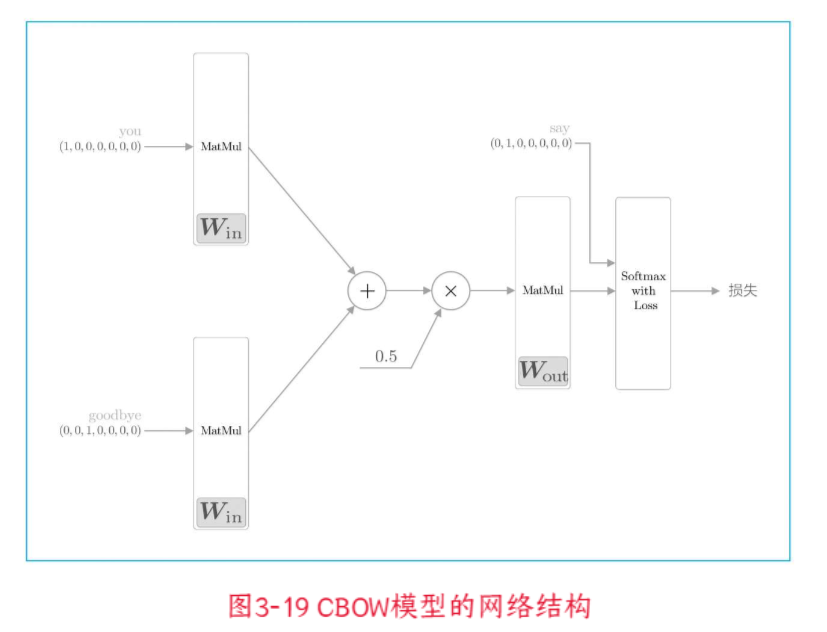

我们将图3-19中的神经网络实现为SimpleCBOW类。首先，让我们看一下SimpleCBOW类的初始化方法：

In [10]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 初始化权重
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 生成层
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 将所有的权重和梯度整理到列表中
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 将单词的分布式表示设置为成员变量
        self.word_vecs = W_in


这里，初始化方法的参数包括词汇个数vocab_size和中间层的神经元个数hidden_size。关于权重的初始化，首先我们生成两个权重（W_in和W_out）​，并用一些小的随机值初始化这两个权重。此外，我们指定NumPy数组的数据类型为astype（'f'）​，这样一来，初始化将使用32位的浮点数。

接着，我们创建必要的层。首先，生成两个输入侧的MatMul层、一个输出侧的MatMul层，以及一个Softmax with Loss层。这里，用来处理输入侧上下文的MatMul层的数量与上下文的单词数量相同（本例中是两个）​。另外，我们使用相同的权重来初始化MatMul层。

最后，将该神经网络中使用的权重参数和梯度分别保存在列表类型的成员变量params和grads中。

接下来，我们来实现神经网络的正向传播forward（​）函数。这个函数接收参数contexts和target，并返回损失（loss）​。

In [11]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 初始化权重
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 生成层
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 将所有的权重和梯度整理到列表中
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 将单词的分布式表示设置为成员变量
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss


这里，我们假定参数contexts是一个三维NumPy数组，即上一节图3-18的例子中（6,2,7）的形状，其中第0维的元素个数是mini-batch的数量，第1维的元素个数是上下文的窗口大小，第2维表示one-hot向量。此外， target是（6,7）这样的二维形状。

最后，我们实现反向传播backward（​）​。这个反向传播的计算图如图3-20所示。

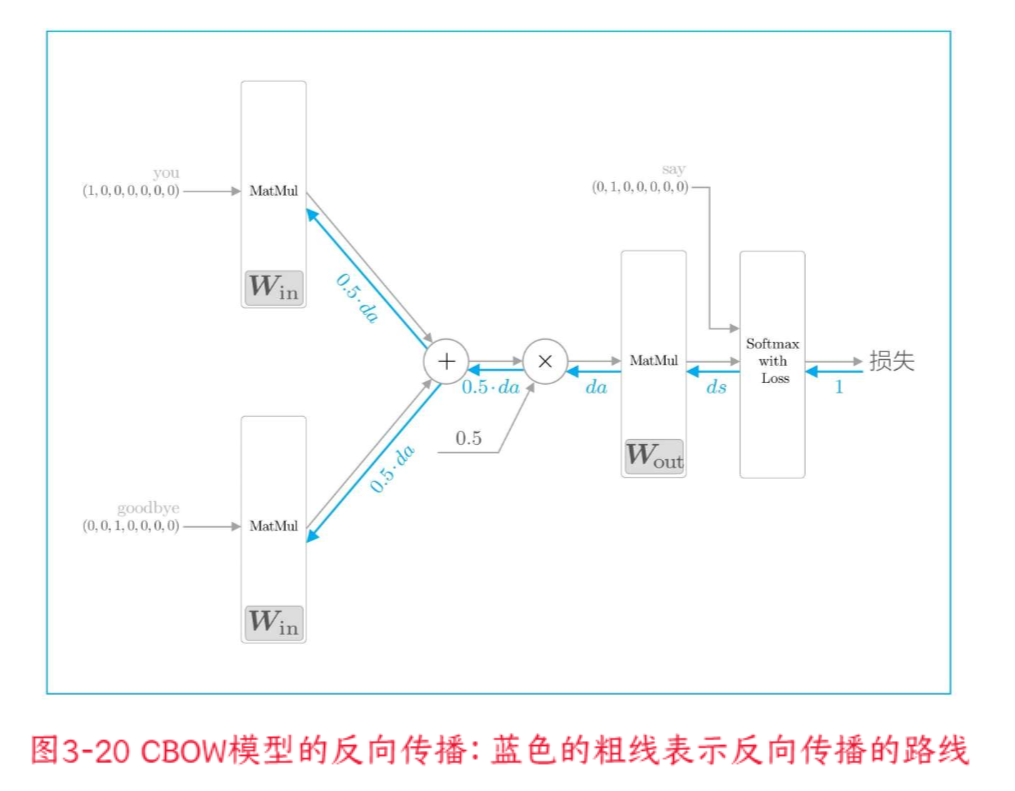

神经网络的反向传播在与正向传播相反的方向上传播梯度。这个反向传播从1出发，并将其传向Softmax with Loss层。然后，将Softmax with Loss层的反向传播的输出ds传到输出侧的MatMul层。

之后就是“+”和“×”运算的反向传播。​“×”的反向传播将正向传播时的输入值“交换”后乘以梯度。​“+”的反向传播则将梯度“原样”传播。我们按照图3-20来实现反向传播。

In [12]:
import sys
sys.path.append('..')
import numpy as np
from common.layers import MatMul, SoftmaxWithLoss

class SimpleCBOW:
    def __init__(self, vocab_size, hidden_size):
        V, H = vocab_size, hidden_size

        # 初始化权重
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(H, V).astype('f')

        # 生成层
        self.in_layer0 = MatMul(W_in)
        self.in_layer1 = MatMul(W_in)
        self.out_layer = MatMul(W_out)
        self.loss_layer = SoftmaxWithLoss()

        # 将所有的权重和梯度整理到列表中
        layers = [self.in_layer0, self.in_layer1, self.out_layer]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 将单词的分布式表示设置为成员变量
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h0 = self.in_layer0.forward(contexts[:, 0])
        h1 = self.in_layer1.forward(contexts[:, 1])
        h = (h0 + h1) * 0.5
        score = self.out_layer.forward(h)
        loss = self.loss_layer.forward(score, target)
        return loss
    
    def backward(self, dout=1):
        ds = self.loss_layer.backward(dout)
        da = self.out_layer.backward(ds)
        da *= 0.5
        self.in_layer1.backward(da)
        self.in_layer0.backward(da)
        return None




至此，反向传播的实现就结束了。我们已经将各个权重参数的梯度保存在了成员变量grads中。因此，通过先调用forward（​）函数，再调用backward（​）函数，grads列表中的梯度被更新。下面，我们继续看一下SimpleCBOW类的学习。

CBOW模型的学习和一般的神经网络的学习完全相同。首先，给神经网络准备好学习数据。然后，求梯度，并逐步更新权重参数。这里，我们使用第1章介绍的Trainer类来执行学习过程，学习的源代码如下所示

| epoch 1 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 2 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 3 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 4 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 5 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 6 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 7 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 8 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 9 |  iter 1 / 2 | time 0[s] | loss 1.95
| epoch 10 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 11 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 12 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 13 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 14 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 15 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 16 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 17 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 18 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 19 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 20 |  iter 1 / 2 | time 0[s] | loss 1.94
| epoch 21 |  iter 1 / 2 | ti

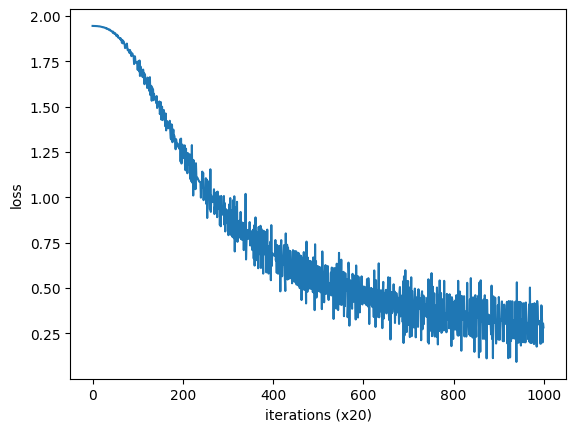

In [13]:
import sys
sys.path.append('..')
from common.trainer import Trainer
from common.optimizer import Adam
# from simple_cbow import SimpleCBOW
from common.util import preprocess, create_contexts_target, convert_one_hot

window_size = 1
hidden_size = 5
batch_size = 3
max_epoch = 1000

text = 'You say goodbye and I say hello.'
corpus, word_to_id, id_to_word = preprocess(text)

vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
target = convert_one_hot(target, vocab_size)
contexts = convert_one_hot(contexts, vocab_size)

model = SimpleCBOW(vocab_size, hidden_size)
optimizer = Adam()
trainer = Trainer(model, optimizer)

trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()


如图3-21所示，通过不断学习，损失在减小，看起来学习进行得一切正常。我们来看一下学习结束后的权重参数。这里，我们取出输入侧的MatMul层的权重，实际确认一下它的内容。因为输入侧的MatMul层的权重已经赋值给了成员变量word_vecs，所以接着上面的代码，我们追加下面的代码。

这里，使用word_vecs这个变量保存权重。word_vecs的各行保存了对应的单词ID的分布式表示。实际运行一下，可以得到下述结果。

In [14]:
word_vecs = model.word_vecs
for word_id, word in id_to_word.items():
    print(word, word_vecs[word_id])


you [0.98635584 1.0002443  0.96919143 0.9714371  1.6835772 ]
say [-0.06766011 -1.2544525  -0.20453922 -1.2349247   1.0732733 ]
goodbye [ 0.94418114  0.9332791   0.9540033   0.9735264  -0.69611174]
and [ 1.6336882 -1.0609869 -1.5808952 -1.0336269  0.8181422]
i [ 0.9534132   0.9404594   0.95896196  0.97362274 -0.68862295]
hello [0.9770955 1.011038  0.9707097 0.9530641 1.6787373]
. [-1.3723023 -1.0460436  1.4100859 -1.0503795  1.0202084]


我们终于将单词表示为了密集向量！这就是单词的分布式表示。我们有理由相信，这样的分布式表示能够很好地捕获单词含义。

不过，遗憾的是，这里使用的小型语料库并没有给出很好的结果。当然，主要原因是语料库太小了。如果换成更大、更实用的语料库，相信会获得更好的结果。但是，这样在处理速度方面又会出现新的问题，这是因为当前这个CBOW模型的实现在处理效率方面存在几个问题。下一章我们将改进这个简单的CBOW模型，实现一个“真正的”CBOW模型。

### CBOW模型和概率

首先简单说明一下概率的表示方法。本书中将概率记为P（·）​，比如事件A发生的概率记为P（A）​。联合概率记为P（A, B）​，表示事件A和事件B同时发生的概率。

后验概率记为P（A|B）​，字面意思是“事件发生后的概率”​。从另一个角度来看，也可以解释为“在给定事件B（的信息）时事件A发生的概率”​。

下面，我们用概率的表示方法来描述CBOW模型。CBOW模型进行的处理是，当给定某个上下文时，输出目标词的概率。这里，我们使用包含单词w1, w2,···, wT的语料库。如图3-22所示，对第t个单词，考虑窗口大小为1的上下文。

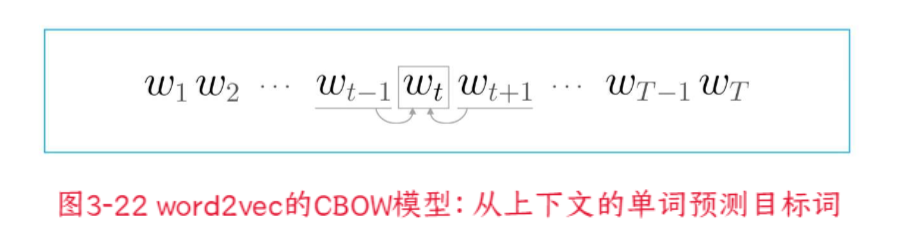

下面，我们用数学式来表示当给定上下文wt-1和wt+1时目标词为wt的概率。使用后验概率，有式（3.1）​：

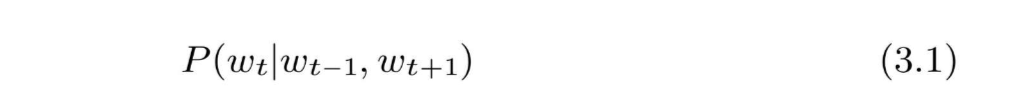

式（3.1）表示“在wt-1和wt+1发生后，wt发生的概率”​，也可以解释为“当给定wt-1和wt+1时，wt发生的概率”​。也就是说，CBOW模型可以建模为式（3.1）​。

这里，使用式（3.1）可以简洁地表示CBOW模型的损失函数。我们把第1章介绍的交叉熵误差函数（式（1.7）​）套用在这里。式（1.7）是
$L = -\sum_k t_k \log y_k$
，其中，yk表示第k个事件发生的概率。tk是监督标签，它是one-hot向量的元素。这里需要注意的是，​“wt发生”这一事件是正确解，它对应的one-hot向量的元素是1，其他元素都是0（也就是说，当wt之外的事件发生时，对应的one-hot向量的元素均为0）​。考虑到这一点，可以推导出下式：

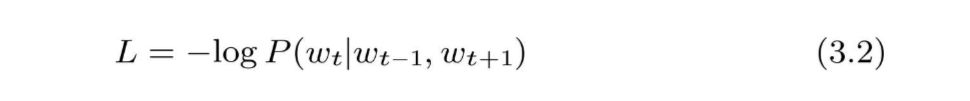

CBOW模型的损失函数只是对式（3.1）的概率取log，并加上负号。顺便提一下，这也称为负对数似然（negative log likelihood）​。式（3.2）是一笔样本数据的损失函数。如果将其扩展到整个语料库，则损失函数可以写为：

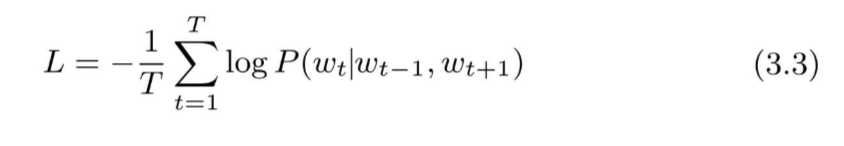

CBOW模型学习的任务就是让式（3.3）表示的损失函数尽可能地小。那时的权重参数就是我们想要的单词的分布式表示。这里，我们只考虑了窗口大小为1的情况，不过其他的窗口大小（或者窗口大小为m的一般情况）也很容易用数学式表示。

### skip-gram模型

如前所述，word2vec有两个模型：一个是我们已经讨论过的CBOW模型；另一个是被称为skip-gram的模型。skip-gram是反转了CBOW模型处理的上下文和目标词的模型。举例来说，两者要解决的问题如图3-23所示。

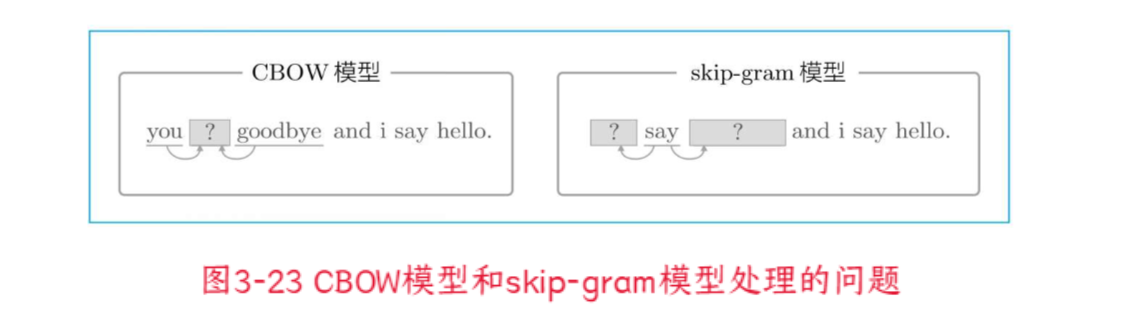

如图3-23所示，CBOW模型从上下文的多个单词预测中间的单词（目标词）​，而skip-gram模型则从中间的单词（目标词）预测周围的多个单词（上下文）​。此时，skip-gram模型的网络结构如图3-24所示。

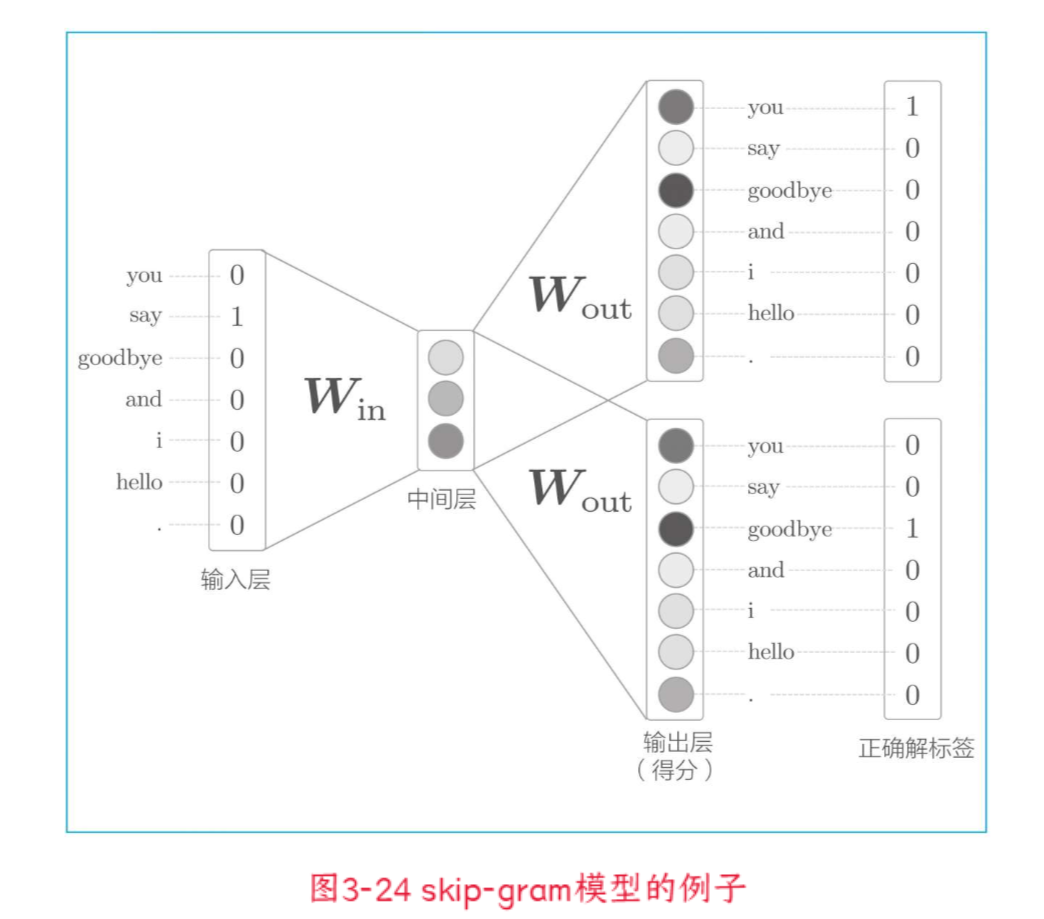

由图3-24可知，skip-gram模型的输入层只有一个，输出层的数量则与上下文的单词个数相等。因此，首先要分别求出各个输出层的损失（通过Softmax with Loss层等）​，然后将它们加起来作为最后的损失。

现在，我们使用概率的表示方法来表示skip-gram模型。我们来考虑根据中间单词（目标词）wt预测上下文wt-1和wt+1的情况。此时，skip-gram可以建模为式（3.4）​：

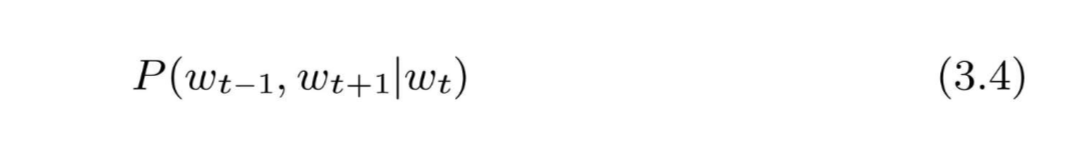

式（3.4）表示“当给定wt时，wt-1和wt+1同时发生的概率”​。这里，在skip-gram模型中，假定上下文的单词之间没有相关性（正确地说是假定“条件独立”​）​，将式（3.4）如下进行分解：

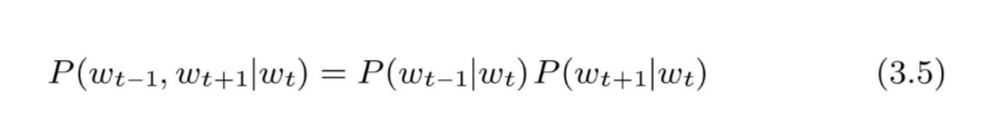

通过将式（3.5）代入交叉熵误差函数，可以推导出skip-gram模型的损失函数：

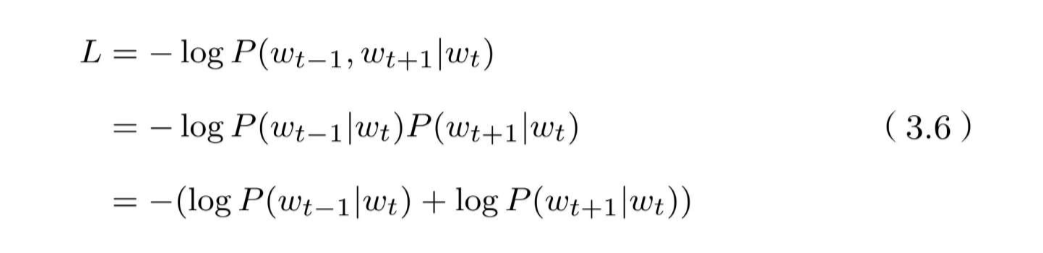

这里利用了对数的性质log xy=log x+log y。如式（3.6）所示，skip-gram模型的损失函数先分别求出各个上下文对应的损失，然后将它们加在一起。式（3.6）是一笔样本数据的损失函数。如果扩展到整个语料库，则skip-gram模型的损失函数可以表示为式（3.7）​：

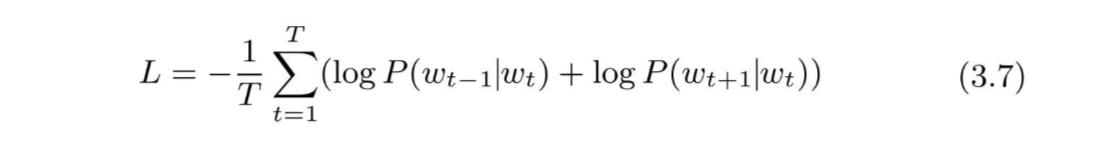

比较式（3.7）和CBOW模型的式（3.3）​，差异是非常明显的。因为skip-gram模型的预测次数和上下文单词数量一样多，所以它的损失函数需要求各个上下文单词对应的损失的总和。而CBOW模型只需要求目标词的损失。以上就是对skip-gram模型的介绍。

那么，我们应该使用CBOW模型和skip-gram模型中的哪一个呢？答案应该是skip-gram模型。这是因为，从单词的分布式表示的准确度来看，在大多数情况下，skip-grm模型的结果更好。特别是随着语料库规模的增大，在低频词和类推问题的性能方面，skip-gram模型往往会有更好的表现（单词的分布式表示的评价方法会在4.4.2节说明）​。此外，就学习速度而言， CBOW模型比skip-gram模型要快。这是因为skip-gram模型需要根据上下文数量计算相应个数的损失，计算成本变大。

### Tip：skip-gram原理

skip-gram模型根据一个单词预测其周围的单词，这是一个非常难的问题。假如我们来解决图3-23中的问题，此时，对于CBOW模型的问题，我们很容易回答“say”​。但是，对于skip-gram模型的问题，则存在许多候选。因此，可以说skip-gram模型要解决的是更难的问题。经过这个更难的问题的锻炼，skip-gram模型能提供更好的单词的分布式表示。

### 基于计数与基于推理的区别


到目前为止，我们已经了解了基于计数的方法和基于推理的方法（特别是word2vec）​。两种方法在学习机制上存在显著差异：基于计数的方法通过对整个语料库的统计数据进行一次学习来获得单词的分布式表示，而基于推理的方法则反复观察语料库的一部分数据进行学习（mini-batch学习）​。这里，我们就其他方面来对比一下这两种方法。

首先，我们考虑需要向词汇表添加新词并更新单词的分布式表示的场景。此时，基于计数的方法需要从头开始计算。即便是想稍微修改一下单词的分布式表示，也需要重新完成生成共现矩阵、进行SVD等一系列操作。相反，基于推理的方法（word2vec）允许参数的增量学习。具体来说，可以将之前学习到的权重作为下一次学习的初始值，在不损失之前学习到的经验的情况下，高效地更新单词的分布式表示。在这方面，基于推理的方法（word2vec）具有优势。

其次，两种方法得到的单词的分布式表示的性质和准确度有什么差异呢？就分布式表示的性质而言，基于计数的方法主要是编码单词的相似性，而word2vec（特别是skip-gram模型）除了单词的相似性以外，还能理解更复杂的单词之间的模式。关于这一点，word2vec因能解开“king-man+woman=queen”这样的类推问题而知名（关于类推问题，我们将在后面章节说明）​。

这里有一个常见的误解，那就是基于推理的方法在准确度方面优于基于计数的方法。实际上，有研究表明，就单词相似性的定量评价而言，基于推理的方法和基于计数的方法难分上下。

### Word2Vec的改进

上一章我们学习了word2vec的机制，并实现了CBOW模型。因为CBOW模型是一个简单的2层神经网络，所以实现起来比较简单。但是，目前的实现存在几个问题，其中最大的问题是，随着语料库中处理的词汇量的增加，计算量也随之增加。实际上，当词汇量达到一定程度之后，上一章的CBOW模型的计算就会花费过多的时间。因此，本章将重点放在word2vec的加速上，来改善word2vec。

具体而言，我们将对上一章中简单的word2vec进行两点改进：引入名为Embedding层的新层，以及引入名为Negative Sampling的新损失函数。这样一来，我们就能够完成一个“真正的”word2vec。完成这个真正的word2vec后，我们将在PTB数据集（一个大小比较实用的语料库）上进行学习，并实际评估所获得的单词的分布式表示的优劣。

在前面，我们实现了图4-1中的CBOW模型。

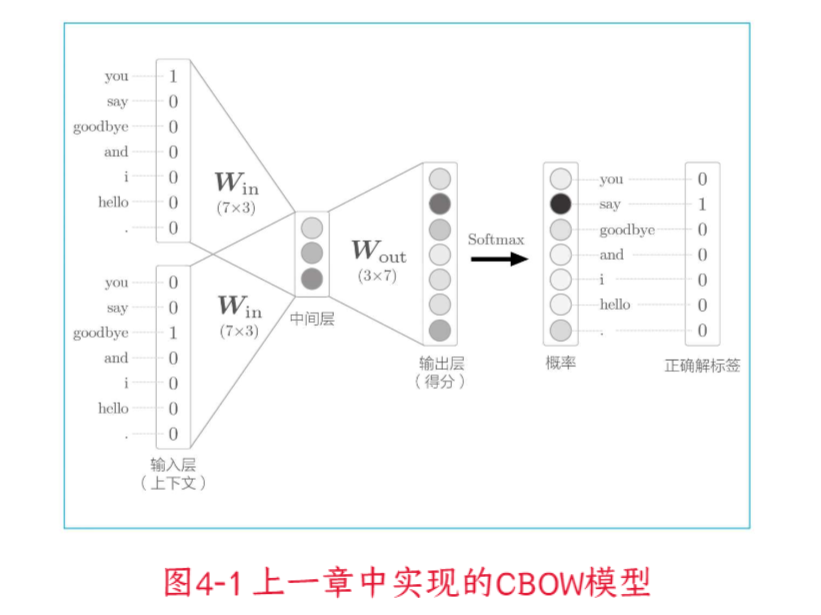

如图4-1所示，上一章的CBOW模型接收拥有2个单词的上下文，并基于它们预测1个单词（目标词）​。此时，通过输入层和输入侧权重（Win）之间的矩阵乘积计算中间层，通过中间层和输出侧权重（Wout）之间的矩阵乘积计算每个单词的得分。这些得分经过Softmax函数转化后，得到每个单词的出现概率。通过将这些概率与正确解标签进行比较（更确切地说，使用交叉熵误差函数）​，从而计算出损失。

在上一章中，我们限定了上下文的窗口大小为1。这相当于只将目标词的前一个和后一个单词作为上下文。本章我们将给模型新增一个功能，使之能够处理任意窗口大小的上下文。

图4-1中的CBOW模型在处理小型语料库时问题不大。实际上，图4-1中处理的词汇量一共只有7个，这个规模自然毫无问题。不过在处理大规模语料库时，这个模型就存在多个问题了。为了指出这些问题，这里我们考虑一个例子。假设词汇量有100万个，CBOW模型的中间层神经元有100个，此时word2vec进行的处理如图4-2所示。

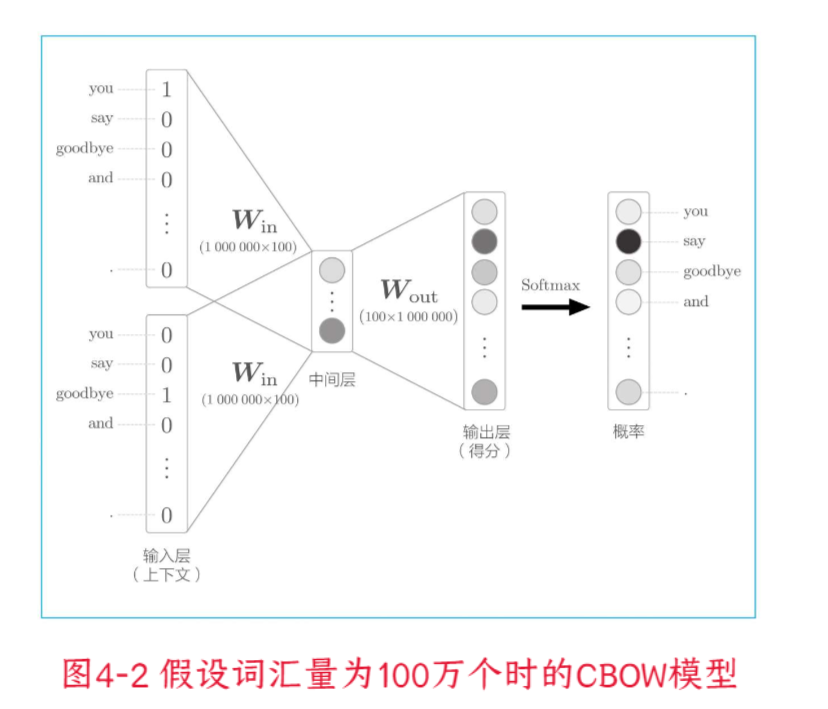

如图4-2所示，输入层和输出层存在100万个神经元。在如此多的神经元的情况下，中间的计算过程需要很长时间。具体来说，以下两个地方的计算会出现瓶颈。

- 输入层的one-hot表示和权重矩阵Win的乘积。
- 中间层和权重矩阵Wout的乘积以及Softmax层的计算。

（这两个问题后面均会解决。）

第1个问题与输入层的one-hot表示有关。这是因为我们用one-hot表示来处理单词，随着词汇量的增加，one-hot表示的向量大小也会增加。比如，在词汇量有100万个的情况下，仅one-hot表示本身就需要占用100万个元素的内存大小。此外，还需要计算one-hot表示和权重矩阵Win的乘积，这也要花费大量的计算资源。关于这个问题，我们会在4.1节中通过引入新的Embedding层来解决。

第2个问题是中间层之后的计算。首先，中间层和权重矩阵Wout的乘积需要大量的计算。其次，随着词汇量的增加，Softmax层的计算量也会增加。关于这些问题，我们将在4.2节通过引入Negative Sampling这一新的损失函数来解决。下面就让我们通过改进来消除这两个瓶颈。

### Embedding层

在上一章的word2vec实现中，我们将单词转化为了one-hot表示，并将其输入了MatMul层，在MatMul层中计算了该one-hot表示和权重矩阵的乘积。这里，我们来考虑词汇量是100万个的情况。假设中间层的神经元个数是100，则MatMul层中的矩阵乘积可画成图4-3。

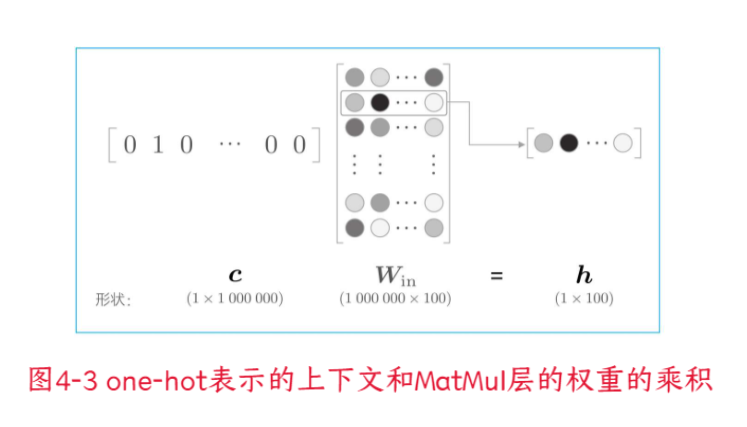

如图4-3所示，如果语料库的词汇量有100万个，则单词的one-hot表示的维数也会是100万，我们需要计算这个巨大向量和权重矩阵的乘积。但是，图4-3中所做的无非是将矩阵的某个特定的行取出来。因此，直觉上将单词转化为one-hot向量的处理和MatMul层中的矩阵乘法似乎没有必要。

现在，我们创建一个从权重参数中抽取“单词ID对应行（向量）​”的层，这里我们称之为Embedding层。顺便说一句，Embedding来自“词嵌入”​（word embedding）这一术语。也就是说，在这个Embedding层存放词嵌入（分布式表示）​。

### Tip:Word Embedding

在自然语言处理领域，单词的密集向量表示称为词嵌入（word embedding）或者单词的分布式表示（distributed representation）​。过去，将基于计数的方法获得的单词向量称为distributional representation，将使用神经网络的基于推理的方法获得的单词向量称为distributed representation。不过，中文里二者都译为“分布式表示”​。

###  Embedding层的实现

从矩阵中取出某一行的处理是很容易实现的。这里，假设权重W是NumPy的二维数组。如果要从这个权重中取出某个特定的行，只需写W[2]或者W[5]​。用Python代码来实现，如下所示。

In [15]:
import numpy as np

W = np.arange(21).reshape(7,3)

print(W)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]
 [15 16 17]
 [18 19 20]]


In [16]:
W[2]

array([6, 7, 8])

In [17]:
W[5]

array([15, 16, 17])

另外，从权重W中一次性提取多行的处理也很简单。只需通过数组指定行号即可，实际的代码如下所示。

In [18]:
idx = np.array([1,0,3,0])
W[idx]

array([[ 3,  4,  5],
       [ 0,  1,  2],
       [ 9, 10, 11],
       [ 0,  1,  2]])

在这个例子中，我们一次性提取了4个索引（1、0、3、0）​。通过将数组作为参数，可以一次性提取多行。顺便说一下，这里的实现假定用于mini-batch处理。

下面，我们来实现Embedding层的forward（​）方法。参照之前的例子，实现如下所示：

In [19]:
class Embedding:
    def __init__(self,W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None
        
    def forward(self,idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out

根据本书的代码规范，使用params和grads作为成员变量，并在成员变量idx中以数组的形式保存需要提取的行的索引（单词ID）​。

接下来，我们考虑反向传播。Embedding层的正向传播只是从权重矩阵W中提取特定的行，并将该特定行的神经元原样传给下一层。因此，在反向传播时，从上一层（输出侧的层）传过来的梯度将原样传给下一层（输入侧的层）​。不过，从上一层传来的梯度会被应用到权重梯度dW的特定行（idx）​，如图4-4所示。

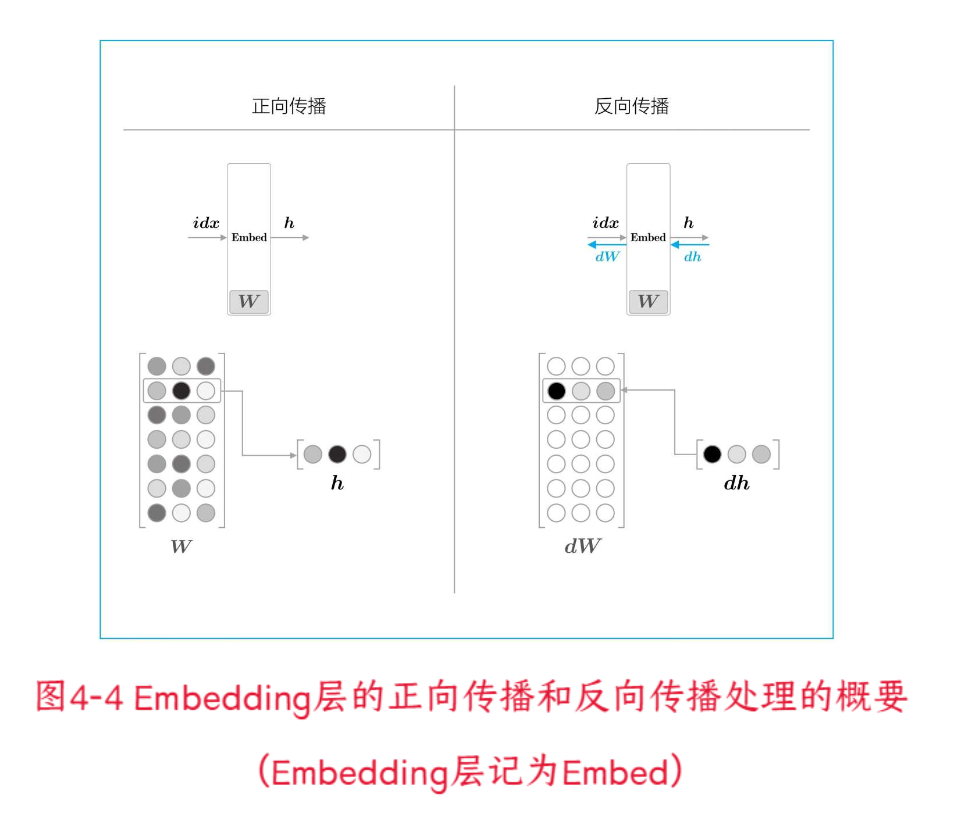

基于以上内容，我们来实现backward（​）​，代码如下所示。

In [20]:
class Embedding:
    def __init__(self,W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None
        
    def forward(self,idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out
    
    def backward(self,dout):
        dW, = self.grads
        dW[...] = 0
        dW[self.idx] = dout# 不太好的方式
        return None

这里，取出权重梯度dW，通过dW[...] = 0将dW的元素设为0（并不是将dW设为0，而是保持dW的形状不变，将它的元素设为0）​。然后，将上一层传来的梯度dout写入idx指定的行。

这里创建了和权重W相同大小的矩阵dW，并将梯度写入了dW对应的行。但是，我们最终想做的事情是更新权重W，所以没有必要特意创建dW（大小与W相同）​。相反，只需把需要更新的行号（idx）及其对应的梯度（dout）保存下来，就可以更新权重（W）的特定行。但是，这里为了兼容已经实现的优化器类（Optimizer）​，所以写成了现在的样子。

实际上，在刚才的backward（​）的实现中，存在一个问题，这一问题发生在idx的元素出现重复时。比如，当idx为[0, 2, 0, 4]时，就会发生图4-5中的问题。

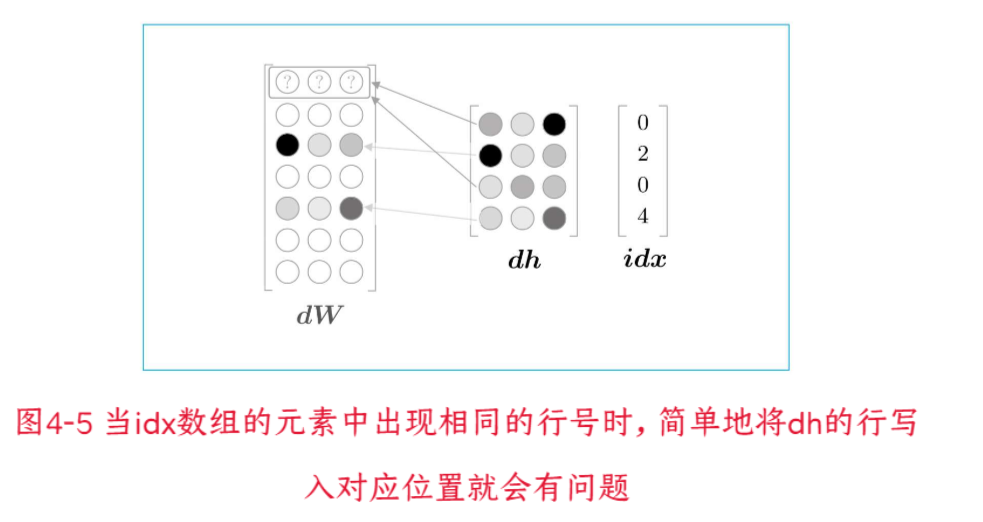

如图4-5所示，我们将dh各行的值写入dW中idx指定的位置。在这种情况下，dW的第0行会被写入两次。这样一来，其中某个值就会被覆盖掉。为了解决这个重复问题，需要进行“加法”​，而不是“写入”​（请读者考虑一下为什么是加法）​。也就是说，应该把dh各行的值累加到dW的对应行中。下面，我们来实现正确的反向传播。

In [21]:
class Embedding:
    def __init__(self,W):
        self.params = [W]
        self.grads = [np.zeros_like(W)]
        self.idx = None
        
    def forward(self,idx):
        W, = self.params
        self.idx = idx
        out = W[idx]
        return out
    
    def backward(self,dout):
        dW, = self.grads
        dW[...] = 0
        
        for i,word_id in enumerate(self.idx):
            dW[word_id] += dout[i]
            # 或者
            # np.add.at(dW,self.idx,dout)
        
        return None
    

这里，我们使用for循环语句将梯度累加到对应索引上。这样一来，即便idx中出现了重复的索引，也能被正确处理。此外，这里使用for循环语句的实现也可以通过NumPy的np.add.at（​）进行。np.add.at（A, idx, B）将B加到A上，此时可以通过idx指定A中需要进行加法的行。

通常情况下，NumPy的内置方法比Python的for循环处理更快。这是因为NumPy的内置方法在底层做了高速化和提高处理效率的优化。因此，上面的代码如果使用np.add.at（​）来实现，效率会比使用for循环处理高得多。

关于Embedding层的实现就介绍到这里。现在，我们可以将word2vec （CBOW模型）的实现中的输入侧的MatMul层换成Embedding层。这样一来，既能减少内存使用量，又能避免不必要的计算。

### Word2Vec再改进

下面，我们来进行word2vec的第2个改进。如前所述，word2vec的另一个瓶颈在于中间层之后的处理，即矩阵乘积和Softmax层的计算。本节的目标就是解决这个瓶颈。这里，我们将采用名为负采样（negative sampling）的方法作为解决方案。使用Negative Sampling替代Softmax，无论词汇量有多大，都可以使计算量保持较低或恒定。

### 中间层之后的计算问题

为了指出中间层之后的计算问题，和上一节一样，我们来考虑词汇量为100万个、中间层的神经元个数为100个的wod2vec（CBOW模型）​。此时， word2vec进行的处理如图4-6所示。

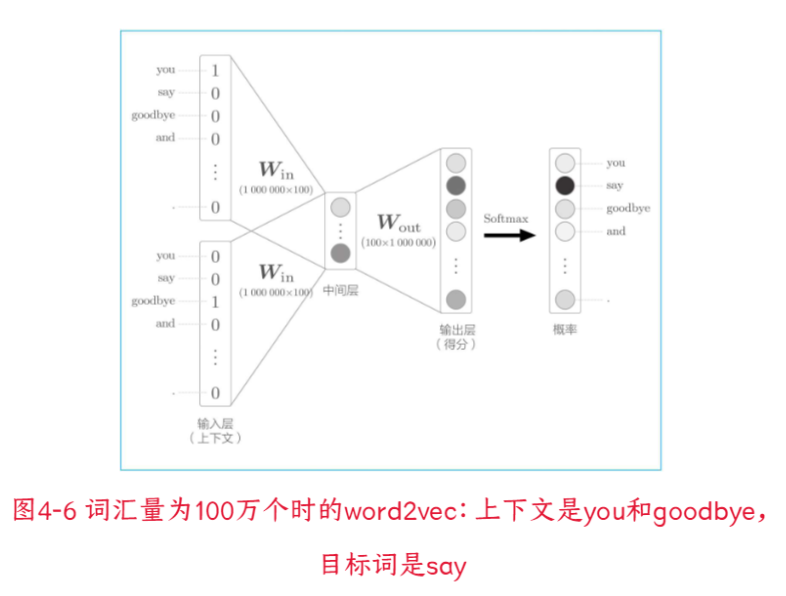

如图4-6所示，输入层和输出层有100万个神经元。在上一节中，通过引入Embedding层，节省了输入层中不必要的计算。剩下的问题就是中间层之后的处理。此时，在以下两个地方需要很多计算时间。

- 中间层的神经元和权重矩阵（Wout）的乘积
- Softmax层的计算

第1个问题在于巨大的矩阵乘积计算。在上面的例子中，中间层向量的大小是100，权重矩阵的大小是100×1000000万，如此巨大的矩阵乘积计算需要大量时间（也需要大量内存）​。此外，因为反向传播时也要进行同样的计算，所以很有必要将矩阵乘积计算“轻量化”​。

第1个问题在于巨大的矩阵乘积计算。在上面的例子中，中间层向量的大小是100，权重矩阵的大小是100×1000000万，如此巨大的矩阵乘积计算需要大量时间（也需要大量内存）​。此外，因为反向传播时也要进行同样的计算，所以很有必要将矩阵乘积计算“轻量化”​。

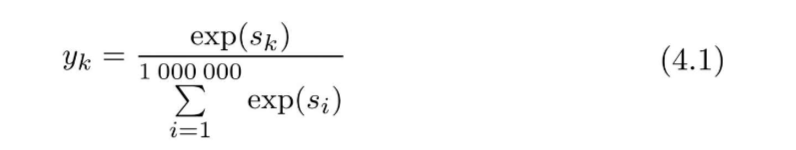

式（4.1）是第k个元素（单词）的Softmax的计算式（各个元素的得分为s1, s2,···）​。因为假定词汇量是100万个，所以式（4.1）的分母需要进行100万次的exp计算。这个计算也与词汇量成正比，因此，需要一个可以替代Softmax的“轻量”的计算。

### 从多分类到二分类

下面，我们来解释一下负采样。这个方法的关键思想在于二分类（binary classification）​，更准确地说，是用二分类拟合多分类（multiclass classification）​，这是理解负采样的重点。

到目前为止，我们处理的都是多分类问题。拿刚才的例子来说，我们把它看作了从100万个单词中选择1个正确单词的任务。那么，可不可以将这个问题处理成二分类问题呢？更确切地说，我们是否可以用二分类问题来拟合这个多分类问题呢？

### 二分类问题
二分类处理的是答案为“Yes/No”的问题。诸如，​“这个数字是7吗？​”​“这是猫吗？​”​“目标词是say吗？​”等，这些问题都可以用“Yes/No”来回答。

到目前为止，我们已经做到了当给定上下文时，以较高的概率预测出作为正确解的单词。比如，当给定you和goodbye时，使神经网络预测出单词say的概率最高。如果学习进展顺利，神经网络就可以进行正确的预测。换句话说，对于“当上下文是you和goodbye时，目标词是什么？​”这个问题，神经网络可以给出正确答案。

现在，我们来考虑如何将多分类问题转化为二分类问题。为此，我们先考察一个可以用“Yes/No”来回答的问题。比如，让神经网络来回答“当上下文是you和goodbye时，目标词是say吗？​”这个问题，这时输出层只需要一个神经元即可。可以认为输出层的神经元输出的是say的得分。

那么，此时CBOW模型进行什么样的处理呢？用图来表示的话，可以画出图4-7。

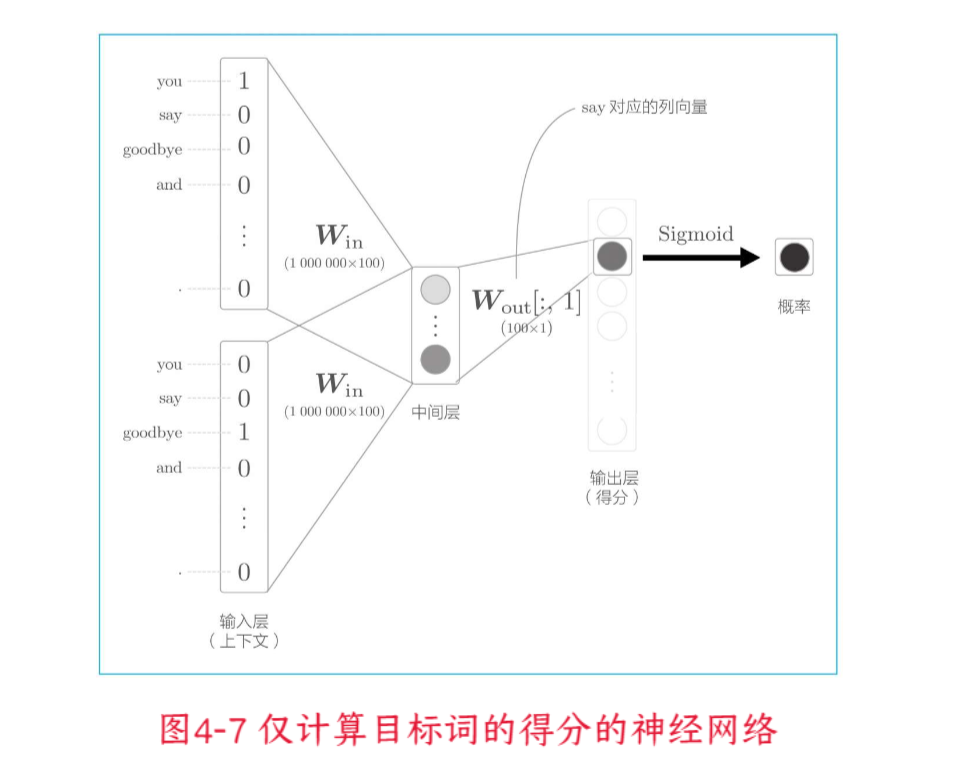

如图4-7所示，输出层的神经元仅有一个。因此，要计算中间层和输出侧的权重矩阵的乘积，只需要提取say对应的列（单词向量）​，并用它与中间层的神经元计算内积即可。这个计算的详细过程如图4-8所示。

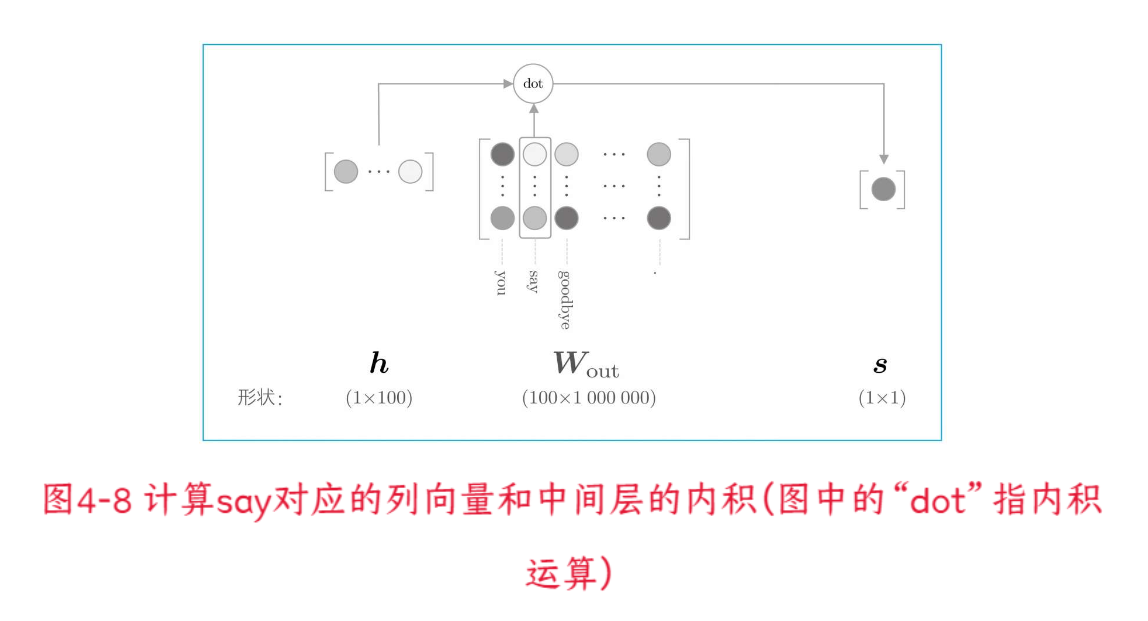

如图4-8所示，输出侧的权重Wout中保存了各个单词ID对应的单词向量。此处，我们提取say这个单词向量，再求这个向量和中间层神经元的内积，这就是最终的得分。

到目前为止，输出层是以全部单词为对象进行计算的。这里，我们仅关注单词say，计算它的得分。然后，使用sigmoid函数将其转化为概率。

### Sigmoid函数和交叉熵误差

要使用神经网络解决二分类问题，需要使用sigmoid函数将得分转化为概率。为了求损失，我们使用交叉熵误差作为损失函数。这些都是二分类神经网络的老套路。

在多分类的情况下，输出层使用Softmax函数将得分转化为概率，损失函数使用交叉熵误差。在二分类的情况下，输出层使用sigmoid函数，损失函数也使用交叉熵误差。

这里我们先回顾一下sigmoid函数，如下式所示：

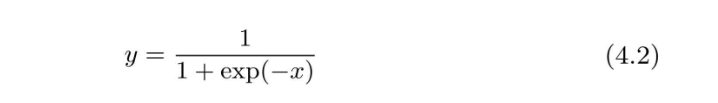

式（4.2）的图像如图4-9中的右图所示。从图中可以看出，sigmoid函数呈S形，输入值x被转化为0到1之间的实数。这里的要点是，sigmoid函数的输出y可以解释为概率。

另外，与sigmoid函数相关的Sigmoid层已经实现好了，如图4-9中的左图所示。

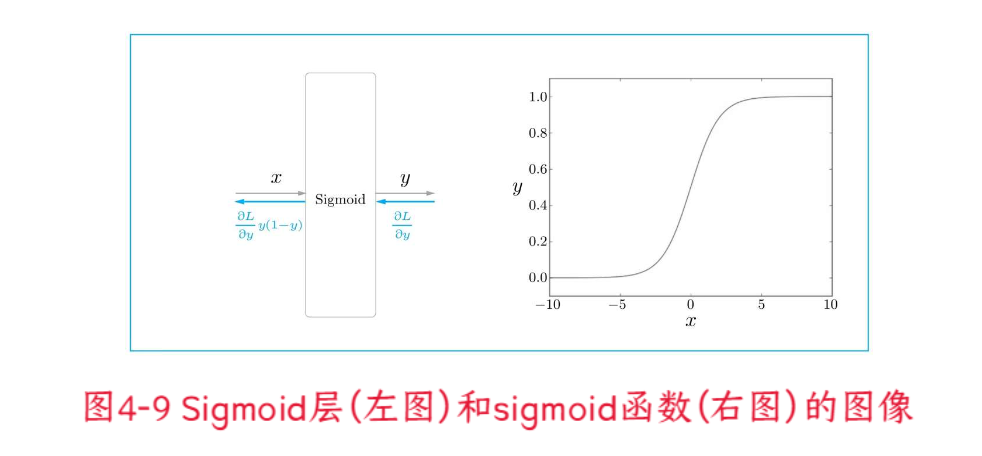

通过sigmoid函数得到概率y后，可以由概率y计算损失。与多分类一样，用于sigmoid函数的损失函数也是交叉熵误差，其数学式如下所示：

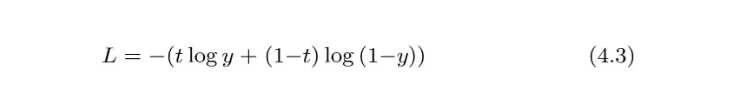

其中，y是sigmoid函数的输出，t是正确解标签，取值为0或1：取值为1时表示正确解是“Yes”​；取值为0时表示正确解是“No”​。因此，当t为1时，输出-log y；当t为0时，输出-log （1-y）​。

### 分类问题常用的Loss函数——交叉熵

二分类和多分类的损失函数均为交叉熵误差，其数学式分别为式（4.3）和式（1.7）​。不过，它们只是写法不同而已，实际上表示的内容是一样的。确切地说，在多分类的情况下，如果输出层只有两个神经元，则式（1.7）和二分类的式（4.3）是完全一致的。因此， Sigmoid with Loss层的实现只要在Softmax with Loss层的基础上稍加改动即可。

下面，我们用图来表示Sigmoid层和Cross Entropy Error层，如图4-10所示。

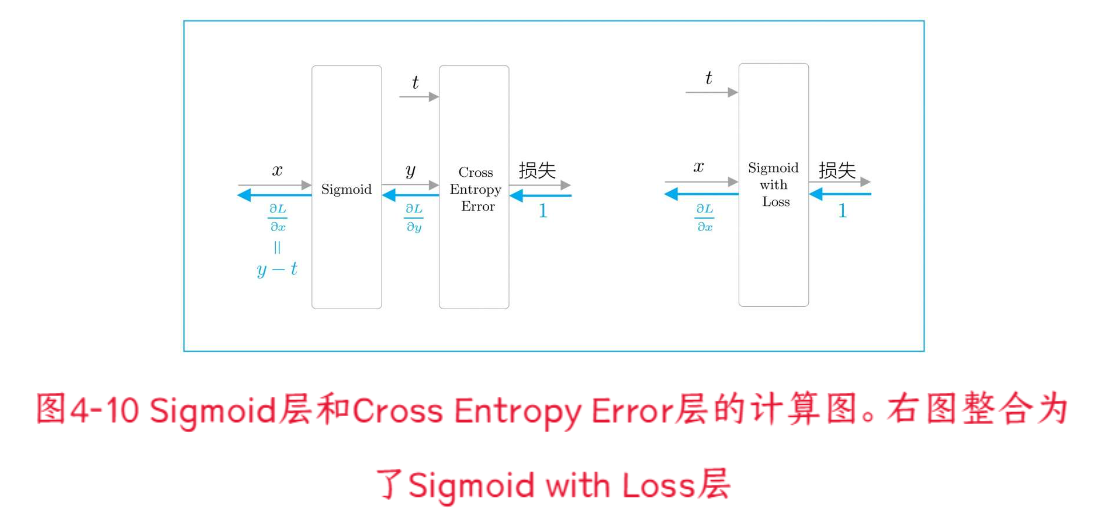

图4-10中值得注意的是反向传播的y-t这个值。y是神经网络输出的概率，t是正确解标签，y-t正好是这两个值的差。这意味着，当正确解标签是1时，如果y尽可能地接近1（100%）​，误差将很小。反过来，如果y远离1，误差将增大。随后，这个误差向前面的层传播，当误差大时，模型学习得多；当误差小时，模型学习得少。

sigmoid函数和交叉熵误差的组合产生了y-t这样一个漂亮的结果。同样地，Softmax函数和交叉熵误差的组合，或者恒等函数和均方误差的组合也会在反向传播时传播y-t。

### 多分类到二分类的实现

下面，我们从实现的角度把之前讲的内容整理一下。前面我们处理了多分类问题，在输出层使用了与词汇量同等数量的神经元，并将它们传给了Softmax层。如果把重点放在“层”和“计算”上，则此时的神经网络可以画成图4-11。

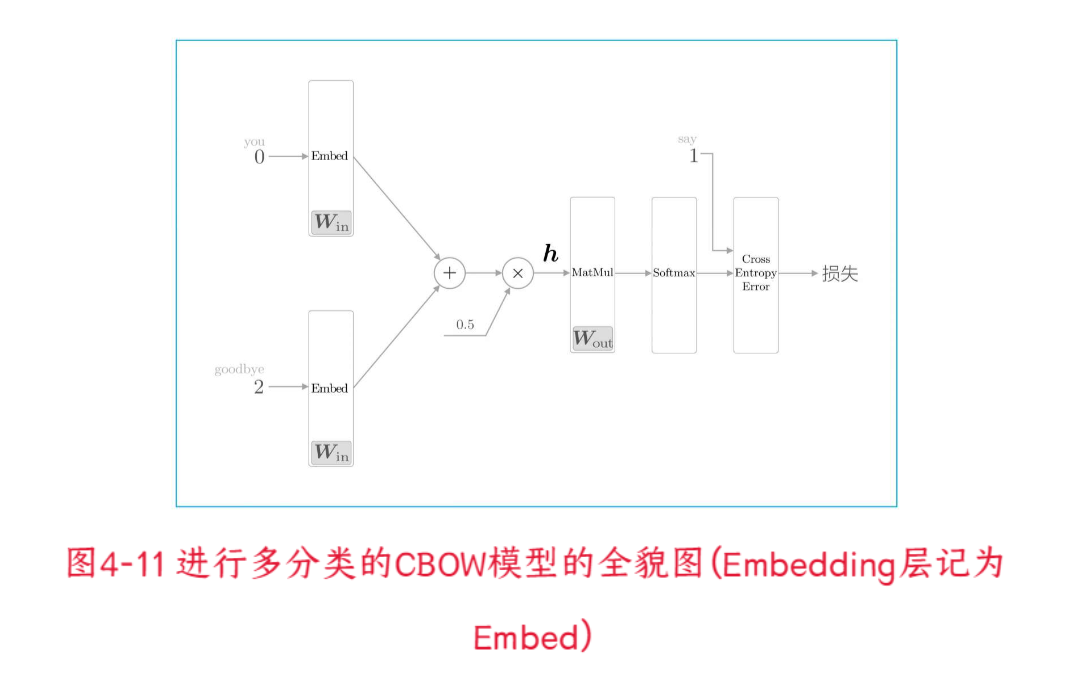

图4-11中展示了上下文是you和goodbye、作为正确解的目标词是say的例子（假定you的单词ID是0,say的单词ID是1,goodbye的单词ID是2）​。在输入层中，为了提取单词ID对应的分布式表示，使用了Embedding层。

### Tip:Embedding

上一节，我们实现了Embedding层，该层提取单词ID对应的分布式表示（单词向量）​。以前我们用的是MatMul层。

现在，我们将图4-11中的神经网络转化成进行二分类的神经网络，网络结构如图4-12所示。

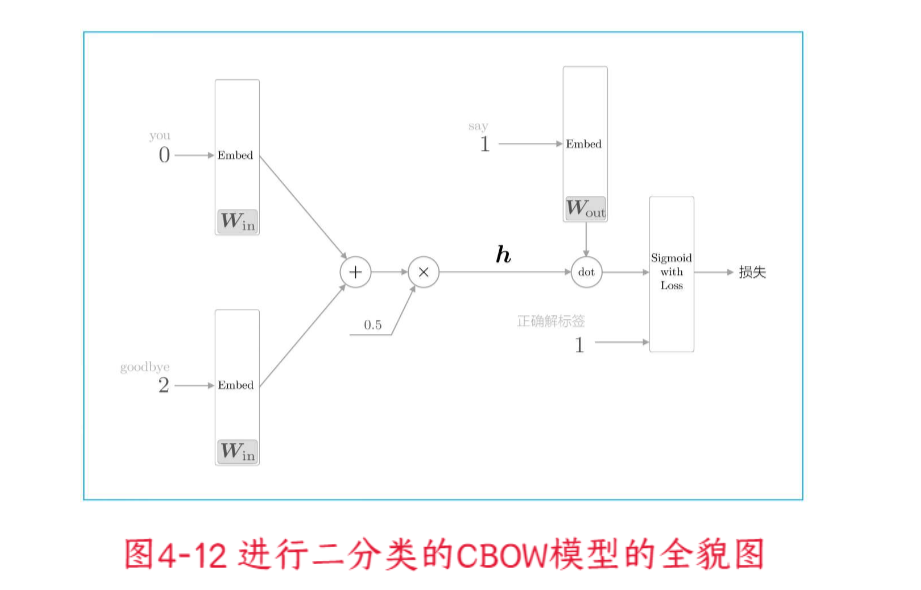

这里，将中间层的神经元记为h，并计算它与输出侧权重Wout中的单词say对应的单词向量的内积。然后，将其输出输入Sigmoid with Loss层，得到最终的损失。

在图4-12中，向Sigmoid with Loss层输入正确解标签1，这意味着现在正在处理的问题的答案是“Yes”​。当答案是“No”时，向Sigmoid with Loss层输入0。

为了便于理解后面的内容，我们把图4-12的后半部分进一步简化。为此，我们引入Embedding Dot层，该层将图4-12中的Embedding层和dot运算（内积）合并起来处理。使用这个层，图4-12的后半部分可以画成图4-13。

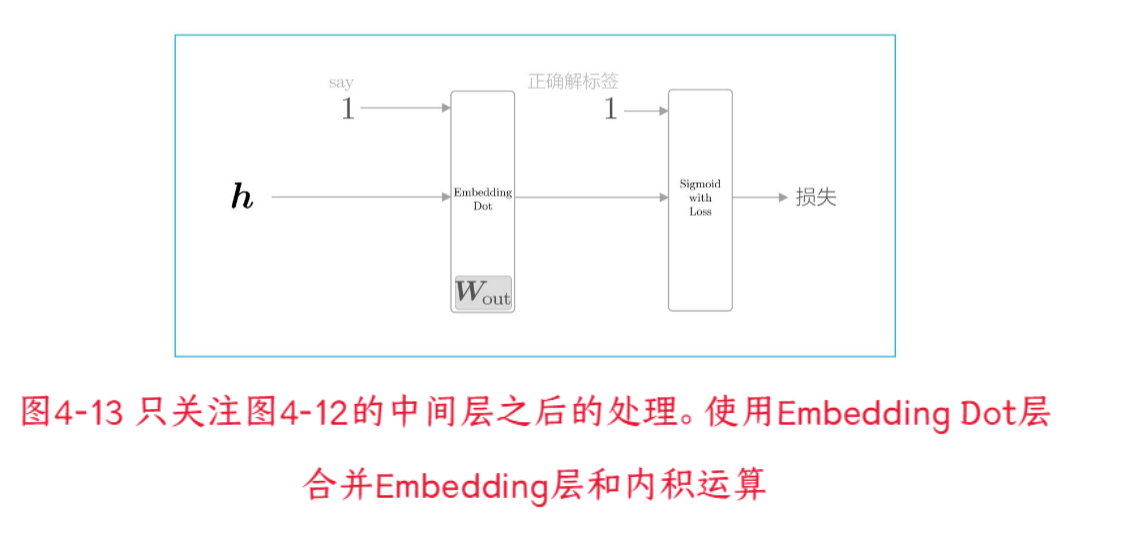

中间层的神经元h流经Embedding Dot层，传给Sigmoid with Loss层。从图中可以看出，使用Embedding Dot层之后，中间层之后的处理被简化了。下面，我们简单地看一下Embedding Dot层的实现，这里我们将这个层实现为EmbeddingDot类

In [22]:
class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh


EmbeddingDot类共有4个成员变量：embed、params、grads和cache。根据本书的代码规范，params保存参数，grads保存梯度。另外，作为缓存， embed保存Embedding层，cache保存正向传播时的计算结果。

正向传播的forward（h, idx）方法的参数接收中间层的神经元（h）和单词ID的NumPy数组（idx）​。这里，idx是单词ID列表，这是因为我们假定了对数据进行mini-batch处理。

在上面的代码中，forward（​）方法首先调用Embedding层的forward（idx）方法，然后通过np.sum（self. target_W * h, axis=1）计算内积。通过观察具体值来理解这个实现会比较快，如图4-14所示。

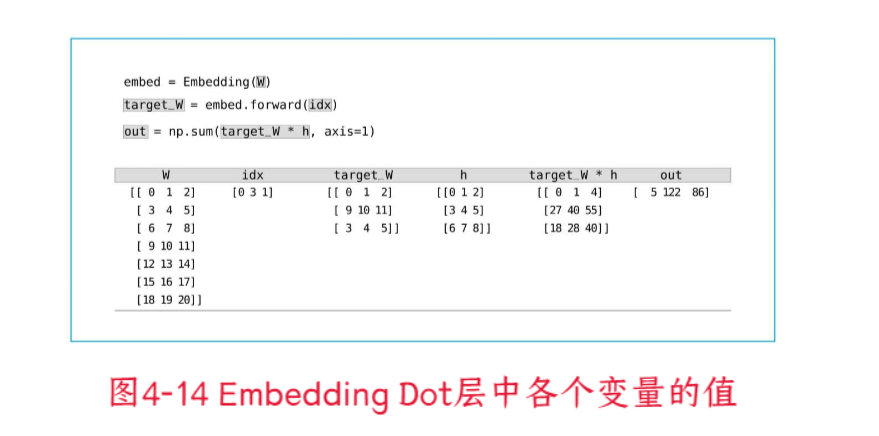

如图4-14所示，准备适当的W、h和idx。这里，idx是[0, 3, 1]​，这个例子表示mini-batch一并处理3笔数据。因为idx是[0, 3, 1]​，所以target_W将提取出W的第0行、第3行和第1行。另外，target_W * h计算对应元素的乘积（NumPy的“*”计算对应元素的乘积）​。然后，对结果逐行（axis=1）进行求和，得到最终的结果out。

以上就是对Embedding Dot层的正向传播的介绍。反向传播以相反的顺序传播梯度，这里我们省略对其实现的说明（并不是特别难，请大家自己思考）​。

### 负采样

至此，我们成功地把要解决的问题从多分类问题转化成了二分类问题。但是，这样问题就被解决了吗？很遗憾，事实并非如此。因为我们目前仅学习了正例（正确答案）​，还不确定负例（错误答案）会有怎样的结果。

现在，我们再来思考一下之前的例子。在之前的例子中，上下文是you和goodbye，目标词是say。我们到目前为止只是对正例say进行了二分类，如果此时模型有“好的权重”​，则Sigmoid层的输出（概率）将接近1。用计算图来表示此时的处理，如图4-15所示。

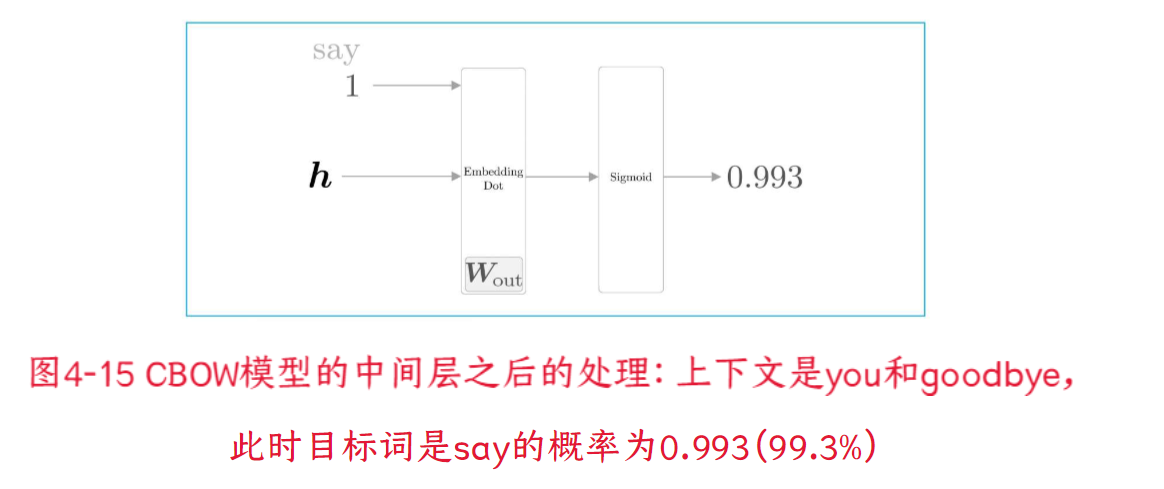

当前的神经网络只是学习了正例say，但是对say之外的负例一无所知。而我们真正要做的事情是，对于正例（say）​，使Sigmoid层的输出接近1；对于负例（say以外的单词）​，使Sigmoid层的输出接近0。用图来表示，如图4-16所示。

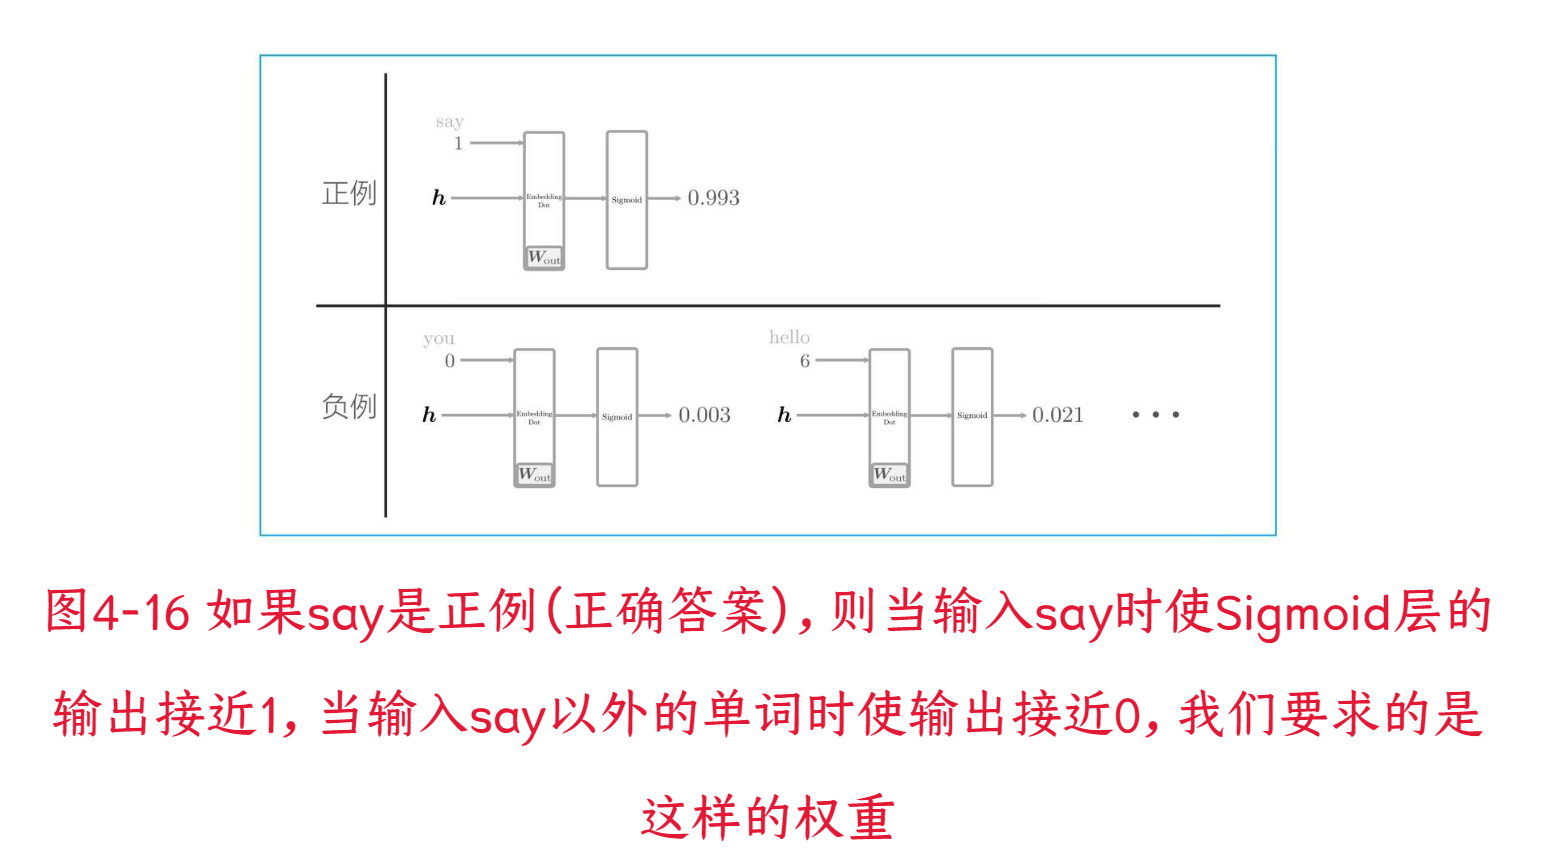

比如，当上下文是you和goodbye时，我们希望目标词是hello（错误答案）的概率较低。在图4-16中，目标词是hello的概率为0.021（2.1%）​，我们要求的就是这种能使输出接近0的权重。

### Tip:为什么要进行负采样

为了把多分类问题处理为二分类问题，对于“正确答案”​（正例）和“错误答案”​（负例）​，都需要能够正确地进行分类（二分类）​。因此，需要同时考虑正例和负例。

那么，我们需要以所有的负例为对象进行学习吗？答案显然是“No”​。如果以所有的负例为对象，词汇量将暴增至无法处理（更何况本章的目的本来就是解决词汇量增加的问题）​。为此，作为一种近似方法，我们将选择若干个（5个或者10个）负例（如何选择将在下文介绍）​。也就是说，只使用少数负例。这就是负采样方法的含义。

总而言之，负采样方法既可以求将正例作为目标词时的损失，同时也可以采样（选出）若干个负例，对这些负例求损失。然后，将这些数据（正例和采样出来的负例）的损失加起来，将其结果作为最终的损失。

下面，让我们结合具体的例子来说明。这里使用与之前相同的例子（正例目标词是say）​。假设选取2个负例目标词hello和i，此时，如果我们只关注CBOW模型的中间层之后的部分，则负采样的计算图如图4-17所示。

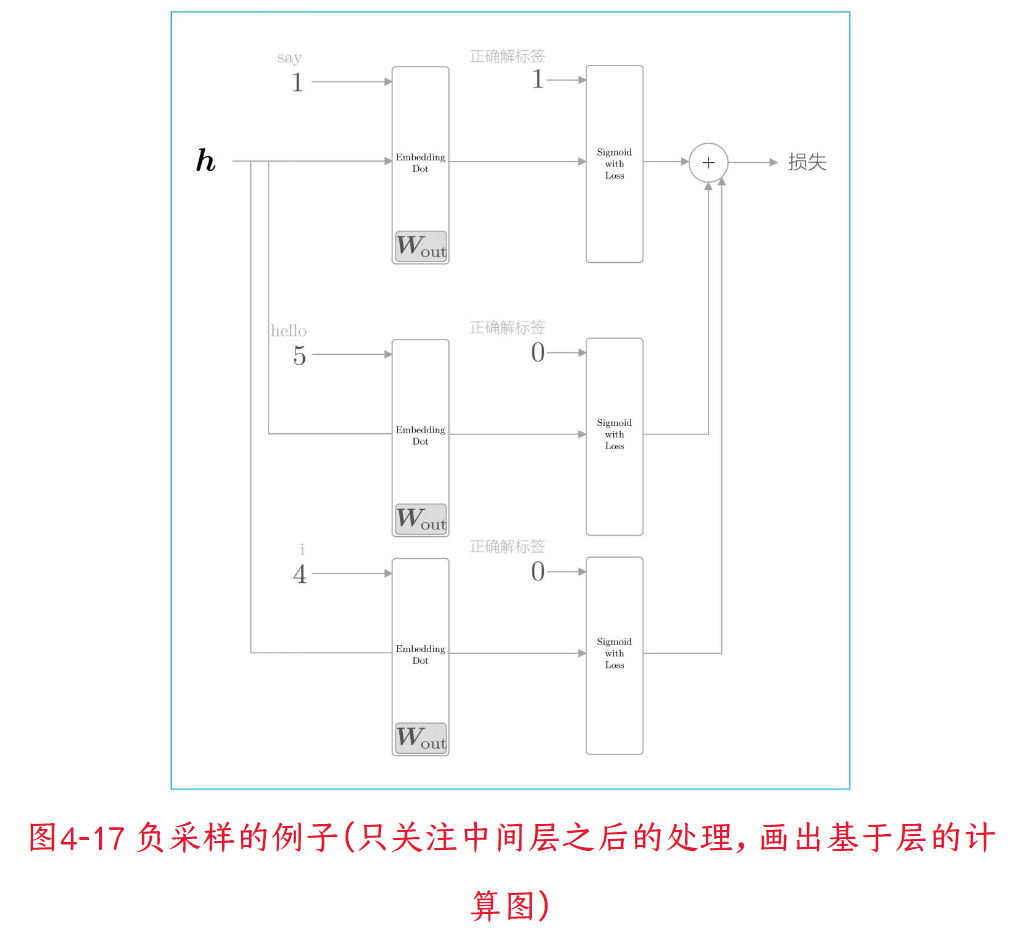

图4-17中需要注意的是对正例和负例的处理。正例（say）和之前一样，向Sigmoid with Loss层输入正确解标签1；而因为负例（hello和i）是错误答案，所以要向Sigmoid with Loss层输入正确解标签0。此后，将各个数据的损失相加，作为最终损失输出。

### 负采样的采样方法

下面我们来看一下如何抽取负例。关于这一点，基于语料库的统计数据进行采样的方法比随机抽样要好。具体来说，就是让语料库中经常出现的单词容易被抽到，让语料库中不经常出现的单词难以被抽到。

基于语料库中单词使用频率的采样方法会先计算语料库中各个单词的出现次数，并将其表示为“概率分布”​，然后使用这个概率分布对单词进行采样（图4-18）​。

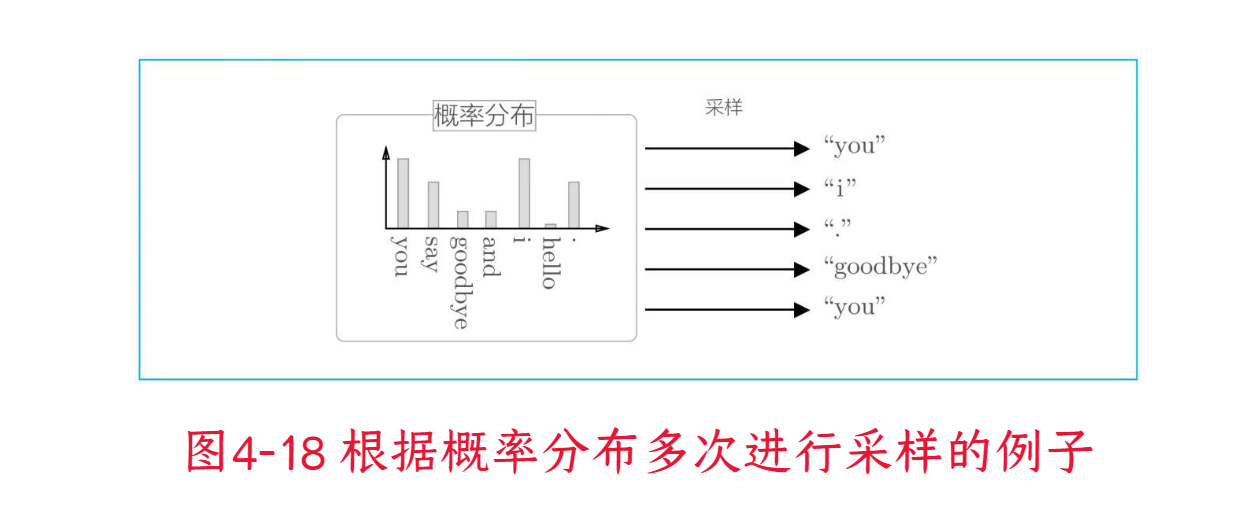

基于语料库中各个单词的出现次数求出概率分布后，只需根据这个概率分布进行采样就可以了。通过根据概率分布进行采样，语料库中经常出现的单词将容易被抽到，而“稀有单词”将难以被抽到。

负采样应当尽可能多地覆盖负例单词，但是考虑到计算的复杂度，有必要将负例限定在较小范围内（5个或者10个）​。这里，如果只选择稀有单词作为负例会怎样呢？结果会很糟糕。因为在现实问题中，稀有单词基本上不会出现。也就是说，处理稀有单词的重要性较低。相反，处理好高频单词才能获得更好的结果。

下面，我们使用Python来说明基于概率分布的采样。为此，可以使用NumPy的np.random.choice（​）方法。这里我们结合几个具体的例子来看一下这个方法的用法。

In [23]:
import numpy as np

# 从0到9的数字中随机选择一个数字
print(np.random.choice(10))  # 例如输出: 7
print(np.random.choice(10))  # 例如输出: 2

# 从words列表中随机选择一个元素
words = ['you', 'say', 'goodbye', 'I', 'hello', '.']
print(np.random.choice(words))  # 例如输出: 'goodbye'

# 有放回采样5次
sample_with_replacement = np.random.choice(words, size=5)
print(sample_with_replacement)  # 例如输出: array(['goodbye', '.', 'hello', 'goodbye', 'say'], dtype='<U7')

# 无放回采样5次
sample_without_replacement = np.random.choice(words, size=5, replace=False)
print(sample_without_replacement)  # 例如输出: array(['hello', '.', 'goodbye', 'I', 'you'], dtype='<U7')

# 基于概率分布进行采样
p = [0.5, 0.1, 0.05, 0.2, 0.05, 0.1]
weighted_sample = np.random.choice(words, p=p)
print(weighted_sample)  # 例如输出: 'you'


1
7
.
['I' 'I' 'I' '.' '.']
['you' 'goodbye' 'hello' '.' 'I']
you


如上所示，np.random.choice（​）可以用于随机抽样。如果指定size参数，将执行多次采样。如果指定replace=False，将进行无放回采样。通过给参数p指定表示概率分布的列表，将进行基于概率分布的采样。剩下的就是使用这个函数抽取负例。

word2vec中提出的负采样对刚才的概率分布增加了一个步骤。如式（4.4）所示，对原来的概率分布取0.75次方。

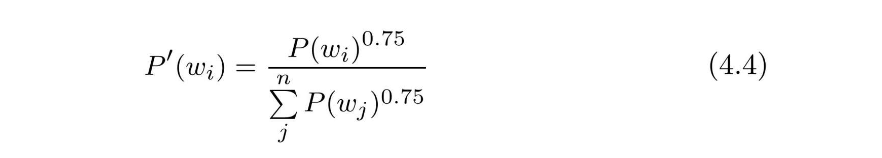

这里，P（wi）表示第i个单词的概率。式（4.4）只是对原来的概率分布的各个元素取0.75次方。不过，为了使变换后的概率总和仍为1，分母需要变成“变换后的概率分布的总和”​。

那么，为什么我们要进行式（4.4）的变换呢？这是为了防止低频单词被忽略。更准确地说，通过取0.75次方，低频单词的概率将稍微变高。我们来看一个具体例子，如下所示。

In [25]:
import numpy as np

# 原始概率分布
p = [0.7, 0.29, 0.01]

# 调整概率分布
new_p = np.power(p, 0.75)  # 对每个元素进行0.75次幂
new_p /= np.sum(new_p)      # 归一化，使总和为1

# 输出新概率分布
print(new_p)  # 例如输出: [0.64196878 0.33150408 0.02652714]


[0.64196878 0.33150408 0.02652714]


根据这个例子，变换前概率为0.01（1%）的元素，变换后为0.026...（2.6... %）​。通过这种方式，取0.75次方作为一种补救措施，使得低频单词稍微更容易被抽到。此外，0.75这个值并没有什么理论依据，也可以设置成0.75以外的值。

如上所示，负采样从语料库生成单词的概率分布，在取其0.75次方之后，再使用之前的np.random.choice（​）对负例进行采样。本书中将这些处理实现为了UnigramSampler类。这里仅简单说明UnigramSampler类的使用方法，其具体实现在ch04/negative_sampling_layer.py中，对细节感兴趣的读者可以参考一下。

unigram是“1个（连续）单词”的意思。同样地，bigram是“2个连续单词”的意思，trigram是“3个连续单词”的意思。这里使用UnigramSampler这个名字，是因为我们以1个单词为对象创建概率分布。如果是bigram，则以‘（ you', ‘say'）​、‘（you',‘goodbye'）……这样的2个单词的组合为对象创建概率分布。在进行初始化时，UnigramSampler类取3个参数，分别是单词ID列表格式的corpus、对概率分布取的次方值power（默认值是0.75）和负例的采样个数sample_size。UnigramSampler类有get_negative_sample（target）方法，该方法以参数target指定的单词ID为正例，对其他的单词ID进行采样。下面，我们来看一个简单的UnigramSampler类的使用示例。

In [27]:
# import numpy as np

# # 创建语料库
# corpus = np.array([0, 1, 2, 3, 4, 1, 2, 3])
# power = 0.75
# sample_size = 2

# # 初始化 UnigramSampler
# sampler = UnigramSampler(corpus, power, sample_size)

# # 目标样本
# target = np.array([1, 3, 0])

# # 获取负样本
# negative_sample = sampler.get_negative_sample(target)

# # 输出负样本
# print(negative_sample)
# # 例如输出:
# # [[0 3]
# #  [1 2]
# #  [2 3]]


这里，考虑将[1, 3, 0]这3个数据的mini-batch作为正例。此时，对各个数据采样2个负例。在上面的例子中，可知第1个数据的负例是[0, 3]​，第2个是[1, 2]​，第3个是[2, 3]​。这样一来，我们就完成了负采样。

### 负采样的实现

最后，我们来实现负采样。我们把它实现为NegativeSamplingLoss类，首先从初始化开始

In [28]:
import numpy as np

class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        
        # 初始化损失层和嵌入层
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        # 收集参数和梯度
        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        # 正例的正向传播
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        # 负例的正向传播
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh


初始化的参数有表示输出侧权重的W、语料库（单词ID列表）corpus、概率分布的次方值power和负例的采样数sample_size。这里，生成上一节所说的UnigramSampler类，并使用成员变量sampler保存。另外，将负例的采样数设置为成员变量sample_size。

成员变量loss_layers和embed_dot_layers中以列表格式保存了必要的层。在这两个列表中生成sample_size + 1个层，这是因为需要生成一个正例用的层和sample_size个负例用的层。这里，我们假设列表的第一个层处理正例。也就是说，loss_layers[0]和embed_dot_layers[0]是处理正例的层。

forward（h, target）方法接收的参数是中间层的神经元h和正例目标词target。这里进行的处理是，首先使用self.sampler采样负例，并设为negative_sample。然后，分别对正例和负例的数据进行正向传播，求损失的和。具体而言，通过Embedding Dot层的forward输出得分，再将这个得分和标签一起输入Sigmoid with Loss层来计算损失。这里需要注意的是，正例的正确解标签为1，负例的正确解标签为0。

反向传播的实现非常简单，只需要以与正向传播相反的顺序调用各层的backward（​）函数即可。在正向传播时，中间层的神经元被复制了多份，这相当于1.3.4.3节中介绍的Repeat节点。因此，在反向传播时，需要将多份梯度累加起来。以上就是负采样的实现的说明。

### CBOW模型的实现

到目前为止，我们进行了word2vec的改进。首先说明了Embedding层，又介绍了负采样的方法，然后对这两者进行了实现。现在我们进一步来实现进行了这些改进的神经网络，并在PTB数据集上进行学习，以获得更加实用的单词的分布式表示。

这里，我们将改进上一章的简单的SimpleCBOW类，来实现CBOW模型。改进之处在于使用Embedding层和Negative Sampling Loss层。此外，我们将上下文部分扩展为可以处理任意的窗口大小。改进版的CBOW类的实现如下所示。

In [29]:
# coding: utf-8
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
from common.layers import Embedding
from codes.negative_sampling_layer import NegativeSamplingLoss

class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        # 初始化权重
        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        # 生成Embedding层
        self.in_layers = []
        for i in range(2 * window_size):  # 窗口大小决定上下文词数
            layer = Embedding(W_in)  # 使用Embedding层处理输入
            self.in_layers.append(layer)
        
        # 负采样损失层
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        # 整理所有层的参数和梯度
        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        # 将单词的分布式表示设置为成员变量
        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        # 处理上下文单词，累加它们的嵌入表示
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        # 计算上下文的平均嵌入表示
        h *= 1 / len(self.in_layers)
        # 使用负采样计算损失
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        # 反向传播负采样损失的梯度
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        # 反向传播到每个上下文嵌入层
        for layer in self.in_layers:
            layer.backward(dout)
        return None


初始化：

这个初始化方法有4个参数。vocab_size是词汇量，hidden_size是中间层的神经元个数，corpus是单词ID列表。另外，通过window_size指定上下文的大小，即上下文包含多少个周围单词。如果window_size是2，则目标词的左右2个单词（共4个单词）将成为上下文。

在SimpleCBOW类（改进前的实现）中，输入侧的权重和输出侧的权重的形状不同，输出侧的权重在列方向上排列单词向量。而CBOW类的输出侧的权重和输入侧的权重形状相同，都在行方向上排列单词向量。这是因为NegativeSamplingLoss类中使用了Embedding层。

在权重的初始化结束后，继续创建层。这里，创建2 * window_size个Embedding层，并将其保存在成员变量in_layers中。然后，创建Negative Sampling Loss层。

在创建好层之后，将神经网络中使用的参数和梯度放入成员变量params和grads中。另外，为了之后可以访问单词的分布式表示，将权重W_in设置为成员变量word_vecs。

正常传播、反向传播：

这里的实现只是按适当的顺序调用各个层的正向传播（或反向传播）​，这是对上一章的SimpleCBOW类的自然扩展。不过，虽然forward （contexts, target）方法取的参数仍是上下文和目标词，但是它们是单词ID形式的（上一章中使用的是one-hot向量，不是单词ID）​，具体示例如图4-19所示。

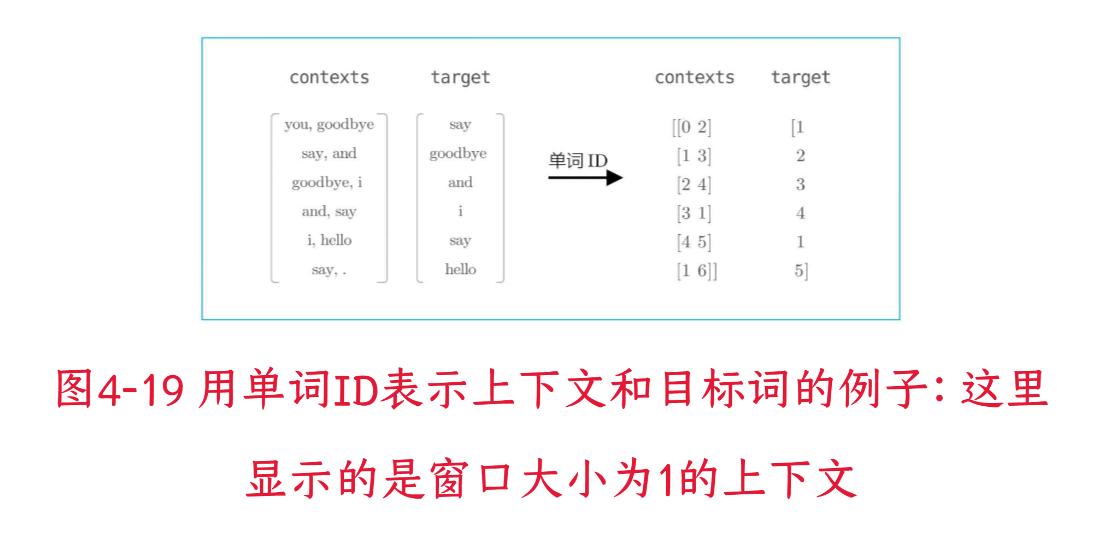

图4-19的右侧显示的单词ID列表是contexts和target的例子。可以看出，contexts是一个二维数组，target是一个一维数组，这样的数据被输入forward（contexts, target）中。以上就是CBOW类的说明。

### CBOW模型的学习代码

最后，我们来实现CBOW模型的学习部分。其实只是复用一下神经网络的学习

In [ ]:
import sys
sys.path.append('..')
import numpy as np
from common import config
# 在用GPU运行时，请打开下面的注释（需要cupy）
# ===============================================
# config.GPU = True
# ===============================================
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from codes.cbow import CBOW
from common.util import create_contexts_target, to_cpu, to_gpu
from dataset import ptb

# 设定超参数
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10

# 读入数据
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)
contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)

# 生成模型等
model = CBOW(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 开始学习
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 保存必要数据，以便后续使用
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)
params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = 'cbow_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)


| epoch 1 |  iter 1 / 9295 | time 0[s] | loss 4.16
| epoch 1 |  iter 21 / 9295 | time 1[s] | loss 4.16
| epoch 1 |  iter 41 / 9295 | time 2[s] | loss 4.15
| epoch 1 |  iter 61 / 9295 | time 3[s] | loss 4.12
| epoch 1 |  iter 81 / 9295 | time 4[s] | loss 4.05
| epoch 1 |  iter 101 / 9295 | time 6[s] | loss 3.92
| epoch 1 |  iter 121 / 9295 | time 7[s] | loss 3.78
| epoch 1 |  iter 141 / 9295 | time 8[s] | loss 3.64
| epoch 1 |  iter 161 / 9295 | time 10[s] | loss 3.50
| epoch 1 |  iter 181 / 9295 | time 11[s] | loss 3.36
| epoch 1 |  iter 201 / 9295 | time 12[s] | loss 3.26
| epoch 1 |  iter 221 / 9295 | time 13[s] | loss 3.16
| epoch 1 |  iter 241 / 9295 | time 15[s] | loss 3.08
| epoch 1 |  iter 261 / 9295 | time 16[s] | loss 3.00
| epoch 1 |  iter 281 / 9295 | time 17[s] | loss 2.96
| epoch 1 |  iter 301 / 9295 | time 18[s] | loss 2.92
| epoch 1 |  iter 321 / 9295 | time 19[s] | loss 2.87
| epoch 1 |  iter 341 / 9295 | time 21[s] | loss 2.84
| epoch 1 |  iter 361 / 9295 | time 22[s] 

本次的CBOW模型的窗口大小为5，隐藏层的神经元个数为100。虽然具体取决于语料库的情况，但是一般而言，当窗口大小为2～10、中间层的神经元个数（单词的分布式表示的维数）为50～500时，结果会比较好。稍后我们会对这些超参数进行讨论。

这次我们利用的PTB语料库比之前要大得多，因此学习需要很长时间（半天左右）​。作为一种选择，我们提供了使用GPU运行的模式。如果要使用GPU运行，需要打开顶部的“# config.GPU = True”​。不过，使用GPU运行需要有一台安装了NVIDIA GPU和CuPy的机器。

在学习结束后，取出权重（输入侧的权重）​，并保存在文件中以备后用（用于单词和单词ID之间的转化的字典也一起保存）​。这里，使用Python的pickle功能进行文件保存。pickle可以将Python代码中的对象保存到文件中（或者从文件中读取对象）​。

codes/cbow_params.pkl中提供了学习好的参数。如果不想等学习结束，可以使用本书提供的学习好的参数。根据学习环境的不同，学习到的权重数据也不一样。这是由权重初始化时用到的随机初始值、mini-bath的随机选取，以及负采样的随机抽样造成的。因为这些随机性，最后得到的权重在各自的环境中会不一样。不过宏观来看，得到的结果（趋势）是类似的。

### CBOW模型的评价

现在，我们来评价一下上一节学习到的单词的分布式表示。这里我们使用第2章中实现的most_similar（​）函数，显示几个单词的最接近的单词

In [ ]:
import sys
sys.path.append('..')
from common.util import most_similar
import pickle

pkl_file = 'cbow_params.pkl'

# 加载参数
with open(pkl_file, 'rb') as f:
    params = pickle.load(f)
    word_vecs = params['word_vecs']
    word_to_id = params['word_to_id']
    id_to_word = params['id_to_word']

# 查询的单词列表
querys = ['you', 'year', 'car', 'toyota']
for query in querys:
    most_similar(query, word_to_id, id_to_word, word_vecs, top=5)


运行上面的代码，可以得以下结果（具体结果会根据各自的学习环境而有所差异）​。

        [query] you
         we: 0.610597074032
         someone: 0.591710150242
         i: 0.554366409779
         something: 0.490028560162
         anyone: 0.473472118378

        [query] year
         month: 0.718261063099
         week: 0.652263045311
         spring: 0.62699586153
         summer: 0.625829637051
         decade: 0.603022158146

        [query] car
         luxury: 0.497202396393
         arabia: 0.478033810854
         auto: 0.471043765545
         disk-drive: 0.450782179832
         travel: 0.40902107954

        [query] toyota
         ford: 0.550541639328
         instrumentation: 0.510020911694
         mazda: 0.49361255765
         bethlehem: 0.474817842245
         nissan: 0.474622786045


我们看一下结果。首先，在查询you的情况下，近似单词中出现了人称代词i（=I）和we等。接着，查询year，可以看到month、week等表示时间区间的具有相同性质的单词。然后，查询toyota，可以得到ford、mazda和nissan等表示汽车制造商的词汇。从这些结果可以看出，由CBOW模型获得的单词的分布式表示具有良好的性质。

此外，由word2vec获得的单词的分布式表示不仅可以将近似单词聚拢在一起，还可以捕获更复杂的模式，其中一个具有代表性的例子是因“king-man+woman=queen”而出名的类推问题（类比问题）​。更准确地说，使用word2vec的单词的分布式表示，可以通过向量的加减法来解决类推问题。

如图4-20所示，要解决类推问题，需要在单词向量空间上寻找尽可能使“man → woman”向量和“king → ?”向量接近的单词。

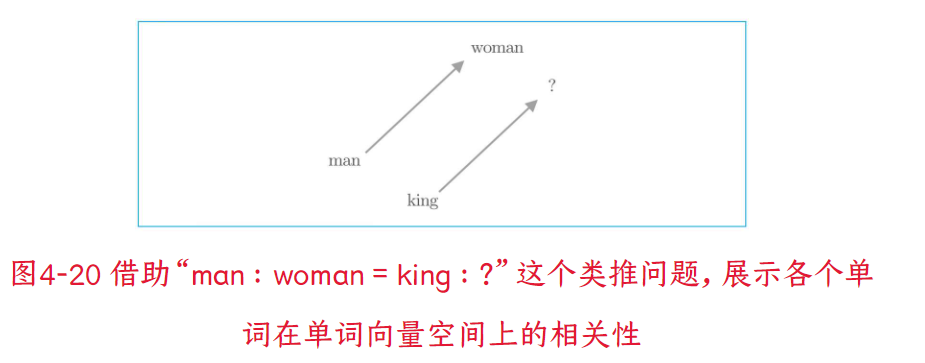

这里用vec（‘man'）表示单词man的分布式表示（单词向量）​。如此一来，图4-20中要求的关联性可以用数学式表示为vec（‘woman'）-vec（‘man'）=vec（?）-vec（‘king'）​。将其变形，有vec（‘king'）+vec（‘woman'）-vec（‘man'）=vec（?）​。也就是说，我们的任务是找到离向量vec（‘king'）+vec（‘woman'）-vec（‘man'）最近的单词向量。本书在common/util.py中提供了实现此逻辑的函数analogy（​）​。使用这个函数，可以用analogy（'man', 'king', 'woman', word_to_id,id_to_word, word_vecs, top=5）这样1行代码来回答刚才的类推问题。此时，输出的结果如下所示。

        [analogy] man:king = woman:?
         word1: 5.003233
         word2: 4.400302
         word3: 4.22342
         word4: 4.003234
         word5: 3.934550


第1行显示的是问题，之后按照得分从高到低的顺序输出5个单词，得分显示在各个单词的旁边。现在，我们来实际解决几个类推问题。下面是4个问题

        analogy（'king', 'man', 'queen',  word_to_id, id_to_word, word_vecs）
        analogy（'take', 'took', 'go',  word_to_id, id_to_word, word_vecs）
        analogy（'car', 'cars', 'child',  word_to_id, id_to_word, word_vecs）
        analogy（'good', 'better', 'bad',  word_to_id, id_to_word, word_vecs）


执行这些代码，可以得到如下结果。

        [analogy] king:man = queen:?
         woman: 5.161407947540283
         veto: 4.928170680999756
         ounce: 4.689689636230469
         earthquake: 4.633471488952637
         successor: 4.6089653968811035

        [analogy] take:took = go:?
         went: 4.548568248748779
         points: 4.248863220214844
         began: 4.090967178344727
         comes: 3.9805688858032227
         oct.: 3.9044761657714844

        [analogy] car:cars = child:?
         children: 5.217921257019043
         average: 4.725458145141602
         yield: 4.208011627197266
         cattle: 4.18687629699707
         priced: 4.178797245025635

        [analogy] good:better = bad:?
         more: 6.647829532623291
         less: 6.063825607299805
         rather: 5.220577716827393
         slower: 4.733833312988281
         greater: 4.672840118408203


结果符合我们的预期。第1个问题是“king : man = queen : ?”​，这里正确地回答了“woman”​。第2个问题是“take : took = go : ?”​，也按预期回答了“went”​。这是捕获了现在时和过去时之间的模式的证据，可以解释为单词的分布式表示编码了时态相关的信息。从第3题可知，单词的单数形式和复数形式之间的模式也被正确地捕获。可惜的是，对于第4题“good :better = bad : ?”​，并没能回答出“worse”​。不过，看到more、less等比较级的单词出现在回答中，说明这些性质也被编码在了单词的分布式表示中。

像这样，使用word2vec获得的单词的分布式表示，可以通过向量的加减法求解类推问题。不仅限于单词的含义，它也捕获了语法中的模式。另外，我们还在word2vec的单词的分布式表示中发现了一些有趣的结果，比如good和best之间存在better这样的关系。

这里的类推问题的结果看上去非常好。不过遗憾的是，这是笔者特意选出来的能够被顺利解决的问题。实际上，很多问题都无法获得预期的结果。这是因为PTB数据集的规模还是比较小。如果使用更大规模的语料库，可以获得更准确、更可靠的单词的分布式表示，从而大大提高类推问题的准确率。

### Wor2Vec相关的其他话题

关于word2vec的机制和实现，我们差不多都介绍完了。本节我们来讨论一些有关word2cev的其他话题。

### Word2Vec的应用例

使用word2vec获得的单词的分布式表示可以用来查找近似单词，但是单词的分布式表示的好处不仅仅在于此。在自然语言处理领域，单词的分布式表示之所以重要，原因就在于迁移学习（transfer learning）​。迁移学习是指在某个领域学到的知识可以被应用于其他领域。

在解决自然语言处理任务时，一般不会使用word2vec从零开始学习单词的分布式表示，而是先在大规模语料库（Wikipedia、Google News等文本数据）上学习，然后将学习好的分布式表示应用于某个单独的任务。比如，在文本分类、文本聚类、词性标注和情感分析等自然语言处理任务中，第一步的单词向量化工作就可以使用学习好的单词的分布式表示。在几乎所有类型的自然语言处理任务中，单词的分布式表示都有很好的效果！

单词的分布式表示的优点是可以将单词转化为固定长度的向量。另外，使用单词的分布式表示，也可以将文档（单词序列）转化为固定长度的向量。目前，关于如何将文档转化为固定长度的向量，相关研究已经进行了很多，最简单的方法是，把文档的各个单词转化为分布式表示，然后求它们的总和。这是一种被称为bag-of-words的不考虑单词顺序的模型（思想）​。此外，使用即将在第5章中说明的循环神经网络，可以以更加优美的方式利用word2vec的单词的分布式表示来将文档转化为固定长度的向量。

将单词和文档转化为固定长度的向量是非常重要的。因为如果可以将自然语言转化为向量，就可以使用常规的机器学习方法（神经网络、SVM等）​，如图4-21所示。

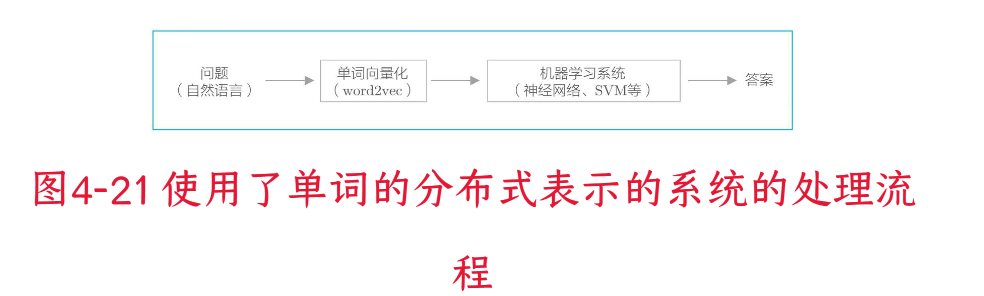

由图4-21可知，如果可以将自然语言书写的问题转化为固定长度的向量，就可以将这个向量作为其他机器学习系统的输入。通过将自然语言转化为向量，可以利用常规的机器学习框架输出目标答案（包括它的学习）​。

在图4-21的流程中，单词的分布式表示的学习和机器学习系统的学习通常使用不同的数据集独立进行。比如，单词的分布式表示使用Wikipedia等通用语料库预先学习好，然后机器学习系统（SVM等）再使用针对当前问题收集到的数据进行学习。但是，如果当前我们面对的问题存在大量的学习数据，则也可以考虑从零开始同时进行单词的分布式表示和机器学习系统的学习。

下面让我们结合具体的例子来说明一下单词的分布式表示的使用方法。假设你现在开发并维护着一个拥有超过1亿用户的智能手机应用，你的公司每天都要收到堆积如山的用户邮件（在Twitter等上也有很多吐槽）​。虽然有一部意见是积极的，但是也存在很多表达不满的用户意见。

为此，你考虑开发一个可以对用户发来的邮件（吐槽等）自动进行分类的系统。如图4-22所示，你想根据邮件的内容将用户情感分为3类。如果可以正确地对用户情感进行分类，就可以按序浏览表达不满的用户邮件。如此一来，或许可以发现应用的致命问题，并尽早采取应对措施，从而提高用户的满意度。

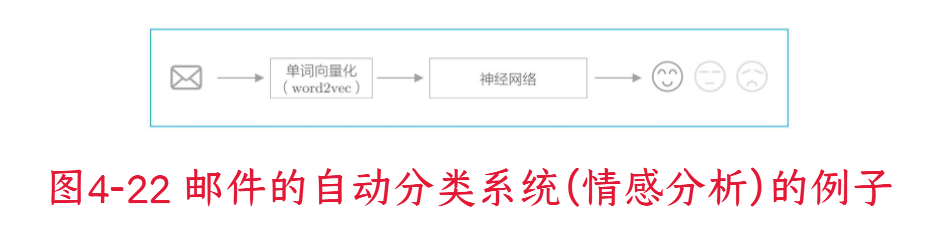

要开发邮件自动分类系统，首先需要从收集数据（邮件）开始。在这个例子中，我们收集用户发送的邮件，并人工对邮件进行标注，打上表示3类情感的标签（positive/neutral/negative）​。标注工作结束后，用学习好的word2vec将邮件转化为向量。然后，将向量化的邮件及其情感标签输入某个情感分类系统（SVM或神经网络等）进行学习。

如本例所示，可以基于单词的分布式表示将自然语言处理问题转化为向量，这样就可以利用常规的机器学习方法来解决问题。另外，这样也能从word2vec的迁移学习中受益。换句话说，利用word2vec的单词的分布式表示，可以期待大多数自然语言处理任务获得精度上的提高。

### 单词向量的评价方法

使用word2vec，我们得到了单词的分布式表示。那么，我们应该如何评价分布式表示的优劣呢？本节我们将简单说明分布式表示的评价方法。

正如上述情感分析的例子那样，在现实世界中，单词的分布式表示往往被用在具体的应用中。我们最终想要的是一个高精度的系统。这里我们必须考虑到的是，这个系统（比如情感分析系统）是由多个子系统组成的。所谓多个子系统，拿刚才的例子来说，包括生成单词的分布式表示的系统（word2vec）​、对特定问题进行分类的系统（比如进行情感分类的SVM等）​。

单词的分布式表示的学习和分类系统的学习有时可能会分开进行。在这种情况下，如果要调查单词的分布式表示的维数如何影响最终的精度，首先需要进行单词的分布式表示的学习，然后再利用这个分布式表示进行另一个机器学习系统的学习。换句话说，在进行两个阶段的学习之后，才能进行评价。在这种情况下，由于需要调试出对两个系统都最优的超参数，所以非常费时。

因此，单词的分布式表示的评价往往与实际应用分开进行。此时，经常使用的评价指标有“相似度”和“类推问题”​。

单词相似度的评价通常使用人工创建的单词相似度评价集来评估。比如，cat和animal的相似度是8,cat和car的相似度是2……类似这样，用0～10的分数人工地对单词之间的相似度打分。然后，比较人给出的分数和word2vec给出的余弦相似度，考察它们之间的相关性。

类推问题的评价是指，基于诸如“king : queen=man : ?”这样的类推问题，根据正确率测量单词的分布式表示的优劣。比如，论文[27]中给出了一个类推问题的评价结果，其部分内容如图4-23所示。

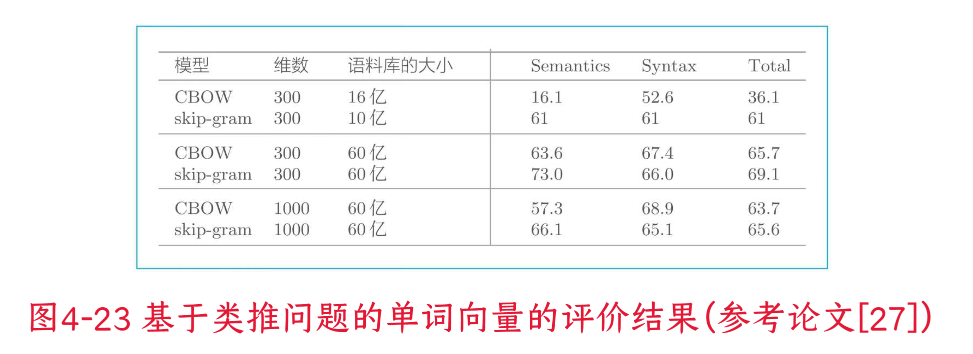

在图4-23中，以word2vec的模型、单词的分布式表示的维数和语料库的大小为参数进行了比较实验，结果在右侧的3列中。图4-23的Semantics列显示的是推断单词含义的类推问题（像“king:queen=actor: actress”这样询问单词含义的问题）的正确率，Syntax列是询问单词形态信息的问题，比如“bad: worst=good:best”​。

由图4-23可知：
- ·模型不同，精度不同（根据语料库选择最佳的模型）
- -·语料库越大，结果越好（始终需要大数据）
- -·单词向量的维数必须适中（太大会导致精度变差）

基于类推问题可以在一定程度上衡量“是否正确理解了单词含义或语法问题”​。因此，在自然语言处理的应用中，能够高精度地解决类推问题的单词的分布式表示应该可以获得好的结果。但是，单词的分布式表示的优劣对目标应用贡献多少（或者有无贡献）​，取决于待处理问题的具体情况，比如应用的类型或语料库的内容等。也就是说，不能保证类推问题的评价高，目标应用的结果就一定好。这一点请一定注意。